# Forest Cover Type Classification

**Dataset source:** [UCI Machine Learning Repository — Covertype](https://archive.ics.uci.edu/dataset/31/covertype)

**Authors:**
- Jarrison Andres Lopez Roldan
- Juliana Andrea Betancur Blandon

## 1. Problem Statement

This project addresses **forest cover type classification** in wilderness areas of the Roosevelt National Forest (northern Colorado). Each observation is a **30 × 30 meter** land cell whose true cover type was obtained from U.S. Forest Service inventory data.

**Forest cover type** is the dominant tree/vegetation class present in that cell (for example, spruce/fir or lodgepole pine). Predicting it from **cartographic** attributes—elevation, slope, distances to water or roads, hillshade indices, wilderness area, and soil type—supports natural-resource planning when field inventories are incomplete for neighboring or unmanaged lands.

Available inputs are 54 cartographic predictors (no remotely sensed imagery). The expected output is one of seven mutually exclusive cover-type labels.

The task is therefore a **supervised Machine Learning classification** problem, specifically **multiclass classification** with seven classes. A model learns from labeled cells `(X, Cover_Type)` and, for a new cell described by the same predictors, predicts its `Cover_Type`.

## 2. Dataset Description

| Property | Description |
|----------|-------------|
| **Name** | Covertype (Forest Cover Type) |
| **Source** | UCI Machine Learning Repository |
| **Observations** | 581,012 |
| **Predictive variables** | 54 |
| **Target** | `Cover_Type` |
| **Number of classes** | 7 |
| **Missing values** | None |
| **Spatial unit** | 30 × 30 meter cells |
| **Feature type** | Cartographic variables (not remotely sensed) |

The study area covers four wilderness areas with limited human disturbance, so observed cover types mainly reflect ecological conditions rather than intensive forest management. Labels come from USFS Region 2 Resource Information System (RIS) data; predictors were derived from USGS and USFS cartographic sources. Features are stored in raw (unscaled) form, with wilderness area and soil type encoded as binary indicator columns.

### 2.1 Predictor Variables

The 54 predictors fall into three groups: **10 quantitative cartographic variables**, **4 wilderness-area indicators**, and **40 soil-type indicators**.

#### Quantitative / cartographic variables

| Variable | Meaning | Unit |
|----------|---------|------|
| `Elevation` | Elevation of the cell | meters |
| `Aspect` | Compass orientation of the slope | degrees azimuth |
| `Slope` | Terrain slope | degrees |
| `Horizontal_Distance_To_Hydrology` | Horizontal distance to the nearest surface water | meters |
| `Vertical_Distance_To_Hydrology` | Vertical distance to the nearest surface water | meters |
| `Horizontal_Distance_To_Roadways` | Horizontal distance to the nearest roadway | meters |
| `Hillshade_9am` | Hillshade index at 9 a.m. (summer solstice) | index, 0–255 |
| `Hillshade_Noon` | Hillshade index at noon (summer solstice) | index, 0–255 |
| `Hillshade_3pm` | Hillshade index at 3 p.m. (summer solstice) | index, 0–255 |
| `Horizontal_Distance_To_Fire_Points` | Horizontal distance to the nearest wildfire ignition point | meters |

#### Wilderness area indicators

`Wilderness_Area_1` … `Wilderness_Area_4` are binary variables (0 = absence, 1 = presence) for:

| Column | Wilderness area |
|--------|-----------------|
| `Wilderness_Area_1` | Rawah |
| `Wilderness_Area_2` | Neota |
| `Wilderness_Area_3` | Comanche Peak |
| `Wilderness_Area_4` | Cache la Poudre |

#### Soil type indicators

`Soil_Type_1` … `Soil_Type_40` are binary indicators (0 = absence, 1 = presence) for 40 USFS Ecological Landtype Units (ELUs) in the study area. Together with the wilderness columns, they encode qualitative site conditions without using remotely sensed imagery.

### 2.2 Target Variable

`Cover_Type` is the **categorical target** to predict. Each observation belongs to exactly one of the following classes:

| Code | Forest cover type |
|------|-------------------|
| 1 | Spruce/Fir |
| 2 | Lodgepole Pine |
| 3 | Ponderosa Pine |
| 4 | Cottonwood/Willow |
| 5 | Aspen |
| 6 | Douglas-fir |
| 7 | Krummholz |

## 3. Environment and Imports

The following libraries support data loading and the exploratory analysis planned for later sections. A fixed `RANDOM_STATE` is defined now so later sampling and validation remain reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 120)

print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"RANDOM_STATE = {RANDOM_STATE}")

numpy: 2.2.4
pandas: 2.2.3
RANDOM_STATE = 42


## 4. Data Loading

The deliverable dataset is loaded from `data/covertype.csv` using a **relative path** so the notebook runs after cloning the repository. This section only confirms that the file loads correctly; a full exploratory analysis is deferred.

In [2]:
DATA_PATH = "data/covertype.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Number of columns:", df.shape[1])
print("\nFirst five rows:")
display(df.head())

print("\nColumn names:")
print(list(df.columns))

print("\nData types:")
print(df.dtypes)

print("\nTarget classes (sorted):", sorted(df["Cover_Type"].unique().tolist()))
print("Total missing values:", int(df.isna().sum().sum()))

Shape: (581012, 55)
Number of columns: 55

First five rows:


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area_1,Wilderness_Area_2,Wilderness_Area_3,Wilderness_Area_4,Soil_Type_1,Soil_Type_2,Soil_Type_3,Soil_Type_4,Soil_Type_5,Soil_Type_6,Soil_Type_7,Soil_Type_8,Soil_Type_9,Soil_Type_10,Soil_Type_11,Soil_Type_12,Soil_Type_13,Soil_Type_14,Soil_Type_15,Soil_Type_16,Soil_Type_17,Soil_Type_18,Soil_Type_19,Soil_Type_20,Soil_Type_21,Soil_Type_22,Soil_Type_23,Soil_Type_24,Soil_Type_25,Soil_Type_26,Soil_Type_27,Soil_Type_28,Soil_Type_29,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5



Column names:
['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area_1', 'Wilderness_Area_2', 'Wilderness_Area_3', 'Wilderness_Area_4', 'Soil_Type_1', 'Soil_Type_2', 'Soil_Type_3', 'Soil_Type_4', 'Soil_Type_5', 'Soil_Type_6', 'Soil_Type_7', 'Soil_Type_8', 'Soil_Type_9', 'Soil_Type_10', 'Soil_Type_11', 'Soil_Type_12', 'Soil_Type_13', 'Soil_Type_14', 'Soil_Type_15', 'Soil_Type_16', 'Soil_Type_17', 'Soil_Type_18', 'Soil_Type_19', 'Soil_Type_20', 'Soil_Type_21', 'Soil_Type_22', 'Soil_Type_23', 'Soil_Type_24', 'Soil_Type_25', 'Soil_Type_26', 'Soil_Type_27', 'Soil_Type_28', 'Soil_Type_29', 'Soil_Type_30', 'Soil_Type_31', 'Soil_Type_32', 'Soil_Type_33', 'Soil_Type_34', 'Soil_Type_35', 'Soil_Type_36', 'Soil_Type_37', 'Soil_Type_38', 'Soil_Type_39', 'Soil_Type_40', 'Cover_Type']

Data types:
Elevation      

The CSV loads successfully with **581,012 rows** and **55 columns**. All columns are integer-typed, the target `Cover_Type` contains classes **1–7**, and there are **no missing values**. The preview matches the expected cartographic and indicator layout.

## 5. Initial Data Verification

The checks below confirm the structural assumptions established when the CSV deliverable was created. This is **integrity verification**, not exploratory analysis.

In [3]:
TARGET = "Cover_Type"
WILDERNESS_COLS = [f"Wilderness_Area_{i}" for i in range(1, 5)]
SOIL_COLS = [f"Soil_Type_{i}" for i in range(1, 41)]
FEATURE_COLS = [c for c in df.columns if c != TARGET]

# Core structural checks
assert df.shape == (581012, 55), f"Unexpected shape: {df.shape}"
assert len(FEATURE_COLS) == 54, f"Unexpected number of predictors: {len(FEATURE_COLS)}"
assert TARGET in df.columns, f"Missing target column: {TARGET}"
assert set(df[TARGET].unique()) == {1, 2, 3, 4, 5, 6, 7}, (
    f"Unexpected Cover_Type values: {sorted(df[TARGET].unique().tolist())}"
)
assert int(df.isna().sum().sum()) == 0, "Missing values detected"

# One-hot style integrity for qualitative indicators
wilderness_sum = df[WILDERNESS_COLS].sum(axis=1)
soil_sum = df[SOIL_COLS].sum(axis=1)
assert (wilderness_sum == 1).all(), "Some rows do not have exactly one wilderness area"
assert (soil_sum == 1).all(), "Some rows do not have exactly one soil type"

print("All initial verification checks passed.")
print(f"Shape: {df.shape}")
print(f"Predictors: {len(FEATURE_COLS)}")
print(f"Target: {TARGET}")
print(f"Cover_Type classes: {sorted(df[TARGET].unique().tolist())}")
print(f"Missing values: {int(df.isna().sum().sum())}")
print(f"Wilderness indicators per row (unique sums): {sorted(wilderness_sum.unique().tolist())}")
print(f"Soil indicators per row (unique sums): {sorted(soil_sum.unique().tolist())}")

All initial verification checks passed.
Shape: (581012, 55)
Predictors: 54
Target: Cover_Type
Cover_Type classes: [1, 2, 3, 4, 5, 6, 7]
Missing values: 0
Wilderness indicators per row (unique sums): [1]
Soil indicators per row (unique sums): [1]


All assertions passed. The loaded table has the expected dimensions, 54 predictors, a valid seven-class `Cover_Type` target, and no missing values. Each row activates exactly one wilderness-area indicator and exactly one soil-type indicator, which is consistent with a proper one-hot encoding of those qualitative attributes.

The next phase will perform Exploratory Data Analysis on the full dataset. Modeling (including the stratified working sample) is not started in this section.

## 6. Exploratory Data Analysis

This section explores the **full** Covertype dataset (581,012 observations) before any modeling. The goal is to understand variable types, scales, distributions, class balance, and relationships that will later inform preprocessing and evaluation choices.

The analysis distinguishes four groups of variables:

1. **Quantitative / cartographic predictors** (10 continuous or integer-valued measures)
2. **Wilderness-area indicators** (4 binary columns)
3. **Soil-type indicators** (40 binary columns)
4. **Target variable** `Cover_Type` (7 mutually exclusive classes)

No rows are removed or transformed in this section.

### 6.1 Variable Types, Ranges, and Scales

The tables below summarize type, range, and scale for all predictors using values computed from the loaded dataset.

In [4]:
QUANTITATIVE_COLS = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points",
]

WILDERNESS_COLS = [f"Wilderness_Area_{i}" for i in range(1, 5)]
SOIL_COLS = [f"Soil_Type_{i}" for i in range(1, 41)]

quantitative_summary = pd.DataFrame({
    "Variable": QUANTITATIVE_COLS,
    "Data type": [str(df[c].dtype) for c in QUANTITATIVE_COLS],
    "Minimum": [df[c].min() for c in QUANTITATIVE_COLS],
    "Maximum": [df[c].max() for c in QUANTITATIVE_COLS],
    "Mean": [df[c].mean() for c in QUANTITATIVE_COLS],
    "Standard deviation": [df[c].std() for c in QUANTITATIVE_COLS],
    "Median": [df[c].median() for c in QUANTITATIVE_COLS],
})

for col in ["Mean", "Standard deviation", "Median"]:
    quantitative_summary[col] = quantitative_summary[col].astype(float).round(3)

display(quantitative_summary)


,Variable,Data type,Minimum,Maximum,Mean,Standard deviation,Median
0,Elevation,int64,1859,3858,2959.365,279.985,2996.0
1,Aspect,int64,0,360,155.657,111.914,127.0
2,Slope,int64,0,66,14.104,7.488,13.0
3,Horizontal_Distance_To_Hydrology,int64,0,1397,269.428,212.549,218.0
4,Vertical_Distance_To_Hydrology,int64,-173,601,46.419,58.295,30.0
5,Horizontal_Distance_To_Roadways,int64,0,7117,2350.147,1559.255,1997.0
6,Hillshade_9am,int64,0,254,212.146,26.770,218.0
7,Hillshade_Noon,int64,0,254,223.319,19.769,226.0
8,Hillshade_3pm,int64,0,254,142.528,38.275,143.0
9,Horizontal_Distance_To_Fire_Points,int64,0,7173,1980.291,1324.195,1710.0


**Interpretation.** The ten quantitative variables use very different numerical scales. Elevation and the long-distance measures (`Horizontal_Distance_To_Roadways`, `Horizontal_Distance_To_Fire_Points`) span thousands of meters, while `Slope` is expressed in degrees (0–66) and hillshade indices occupy a 0–255 range. `Aspect` spans a full 0–360° azimuth circle. `Vertical_Distance_To_Hydrology` includes **negative** values (minimum −173), which is consistent with measuring vertical offset relative to nearest surface water rather than an absolute height.

Because Logistic Regression and SVM are sensitive to feature magnitude when features are left unscaled, these scale differences motivate later use of standardization **inside** each cross-validation fold. Scaling is **not** applied in this EDA section.

In [5]:
wilderness_unique = sorted({int(v) for v in np.unique(df[WILDERNESS_COLS].to_numpy())})
soil_unique = sorted({int(v) for v in np.unique(df[SOIL_COLS].to_numpy())})

print("Unique values in wilderness indicators:", wilderness_unique)
print("Unique values in soil indicators:", soil_unique)

assert wilderness_unique == [0, 1]
assert soil_unique == [0, 1]

wilderness_freq = pd.DataFrame({
    "Variable": WILDERNESS_COLS,
    "Count (value=1)": [int(df[c].sum()) for c in WILDERNESS_COLS],
    "Percentage": [100 * df[c].mean() for c in WILDERNESS_COLS],
})
wilderness_freq["Percentage"] = wilderness_freq["Percentage"].round(3)

soil_freq = pd.DataFrame({
    "Variable": SOIL_COLS,
    "Count (value=1)": [int(df[c].sum()) for c in SOIL_COLS],
    "Percentage": [100 * df[c].mean() for c in SOIL_COLS],
})
soil_freq["Percentage"] = soil_freq["Percentage"].round(4)
soil_freq = soil_freq.sort_values("Count (value=1)", ascending=False).reset_index(drop=True)

print("\nWilderness area frequencies:")
display(wilderness_freq)
print("\nSoil type frequencies (sorted by count, descending):")
display(soil_freq)


Unique values in wilderness indicators: [0, 1]
Unique values in soil indicators: [0, 1]

Wilderness area frequencies:


,Variable,Count (value=1),Percentage
0,Wilderness_Area_1,260796,44.887
1,Wilderness_Area_2,29884,5.143
2,Wilderness_Area_3,253364,43.607
3,Wilderness_Area_4,36968,6.363



Soil type frequencies (sorted by count, descending):


,Variable,Count (value=1),Percentage
0,Soil_Type_29,115247,19.8356
1,Soil_Type_23,57752,9.9399
2,Soil_Type_32,52519,9.0392
3,Soil_Type_33,45154,7.7716
4,Soil_Type_22,33373,5.7439
5,Soil_Type_10,32634,5.6168
6,Soil_Type_30,30170,5.1927
7,Soil_Type_12,29971,5.1584
8,Soil_Type_31,25666,4.4175
9,Soil_Type_24,21278,3.6622


**Interpretation (binary predictors).** All wilderness and soil columns take only the values **0** (absence) and **1** (presence). Because each row activates exactly one wilderness indicator and exactly one soil indicator (verified in Section 5), these groups behave as one-hot encodings of qualitative attributes. Their frequencies are uneven: some wilderness areas and soil types are common, while others are rare. Detailed wilderness and soil distributions are interpreted in Sections 6.6 and 6.7.

### 6.2 Descriptive Statistics

The following `describe()` summary focuses on the ten quantitative variables for readability (binary columns are summarized by frequencies above).

In [6]:
quantitative_describe = df[QUANTITATIVE_COLS].describe().T
quantitative_describe["skewness"] = df[QUANTITATIVE_COLS].skew()
display(quantitative_describe.round(3))


,count,mean,std,min,25%,50%,75%,max,skewness
Elevation,581012.0,2959.365,279.985,1859.0,2809.0,2996.0,3163.0,3858.0,-0.818
Aspect,581012.0,155.657,111.914,0.0,58.0,127.0,260.0,360.0,0.403
Slope,581012.0,14.104,7.488,0.0,9.0,13.0,18.0,66.0,0.789
Horizontal_Distance_To_Hydrology,581012.0,269.428,212.549,0.0,108.0,218.0,384.0,1397.0,1.140
Vertical_Distance_To_Hydrology,581012.0,46.419,58.295,-173.0,7.0,30.0,69.0,601.0,1.790
Horizontal_Distance_To_Roadways,581012.0,2350.147,1559.255,0.0,1106.0,1997.0,3328.0,7117.0,0.714
Hillshade_9am,581012.0,212.146,26.770,0.0,198.0,218.0,231.0,254.0,-1.181
Hillshade_Noon,581012.0,223.319,19.769,0.0,213.0,226.0,237.0,254.0,-1.063
Hillshade_3pm,581012.0,142.528,38.275,0.0,119.0,143.0,168.0,254.0,-0.277
Horizontal_Distance_To_Fire_Points,581012.0,1980.291,1324.195,0.0,1024.0,1710.0,2550.0,7173.0,1.289


**Interpretation.** Means and medians are close for some variables (for example hillshade indices) and farther apart for right-skewed distance measures such as hydrology, roadways, and fire-point distances, where the mean exceeds the median. Standard deviations are large for roadway and fire-point distances, reflecting wide geographic spread. Extreme minima/maxima exist (for example very large horizontal distances), but an extreme value alone is not evidence of a recording error in cartographic data. Skewness values highlight asymmetry that will also appear in the histograms below.

### 6.3 Distribution of Quantitative Variables

Histograms of the ten quantitative predictors (professor-style distribution screening).

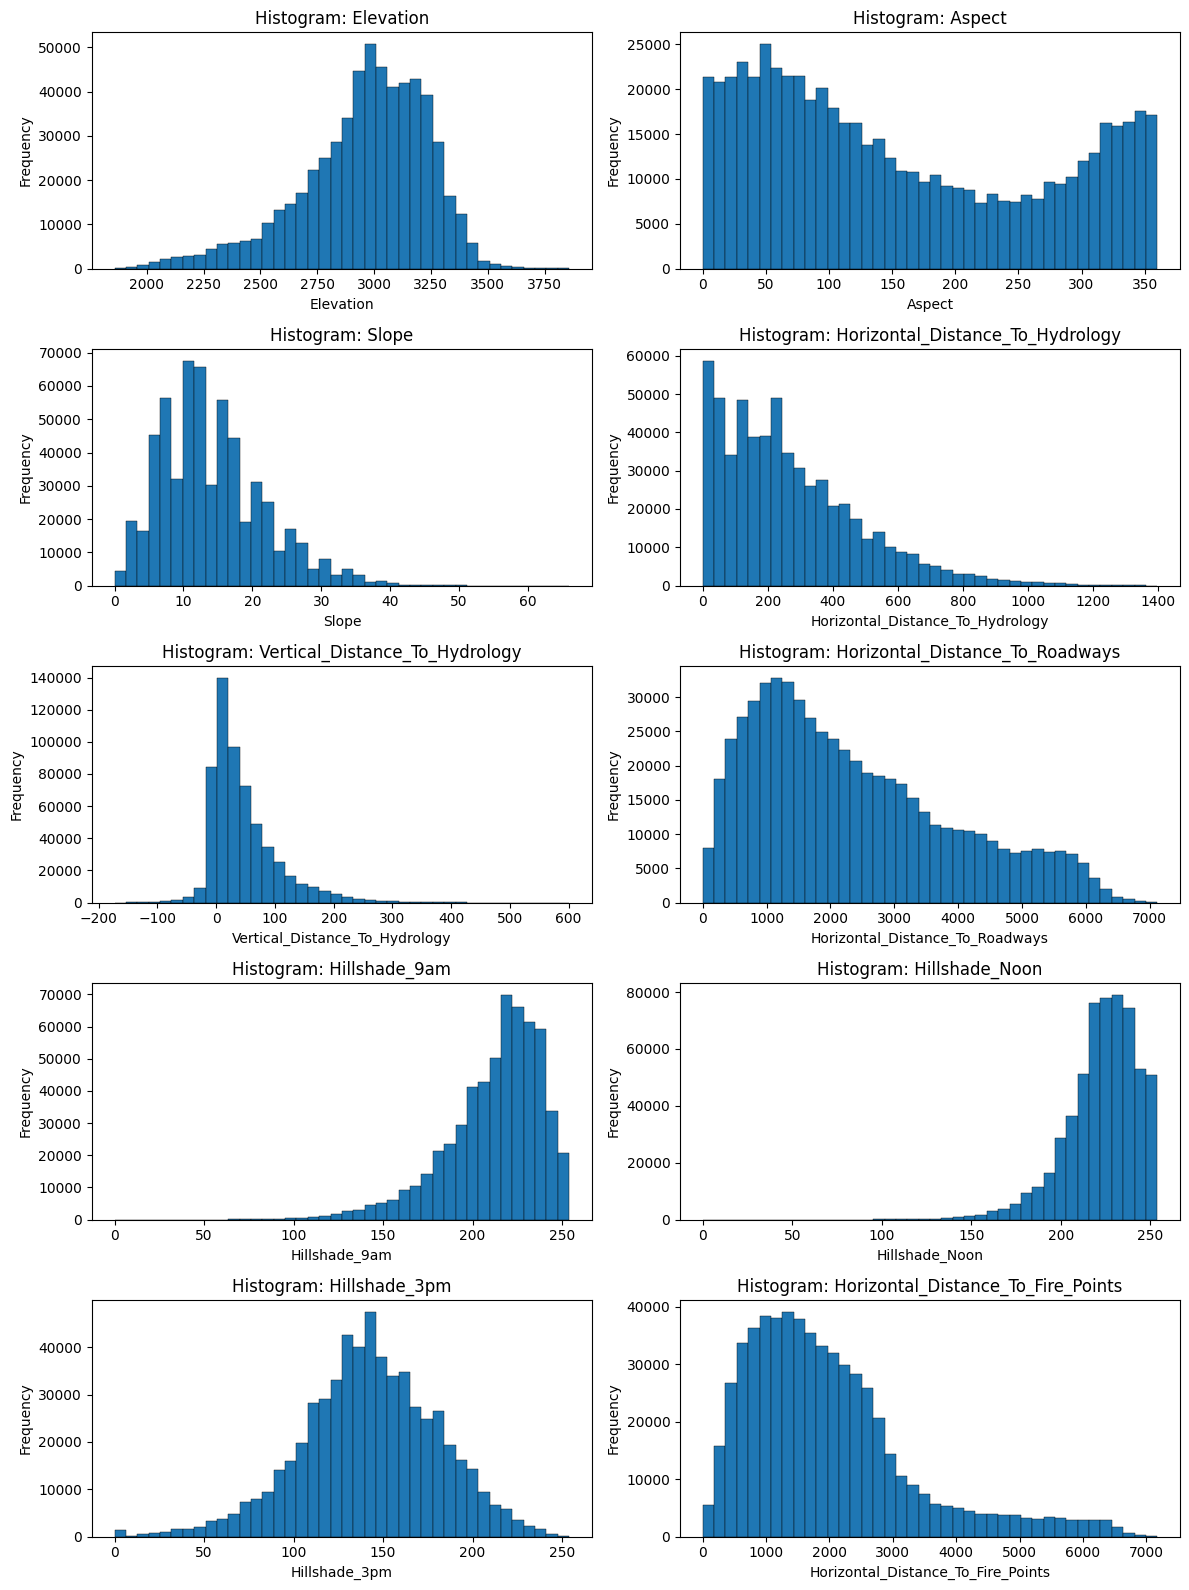

In [7]:
fig, axes = plt.subplots(5, 2, figsize=(12, 16))
axes = axes.ravel()

for ax, col in zip(axes, QUANTITATIVE_COLS):
    ax.hist(df[col], bins=40, edgecolor="black", linewidth=0.3)
    ax.set_title(f"Histogram: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


**Interpretation.** Several distance-related variables (`Horizontal_Distance_To_Hydrology`, `Vertical_Distance_To_Hydrology`, `Horizontal_Distance_To_Roadways`, `Horizontal_Distance_To_Fire_Points`) are concentrated at lower values with long right tails. `Elevation` is concentrated in the mid-to-high range of its span and is mildly left-skewed. `Aspect` is relatively spread across azimuths, with uneven concentration rather than a single narrow peak. `Slope` is concentrated at modest angles with a right tail toward steeper slopes. Hillshade variables, especially at 9 a.m. and noon, are concentrated toward higher index values, while `Hillshade_3pm` is more symmetric around mid-range values. These patterns describe shape and concentration only; they do not imply causal mechanisms.

### 6.4 Boxplot Analysis

Because quantitative variables have incompatible scales, each variable is shown in its own boxplot panel rather than a single shared-axis plot.

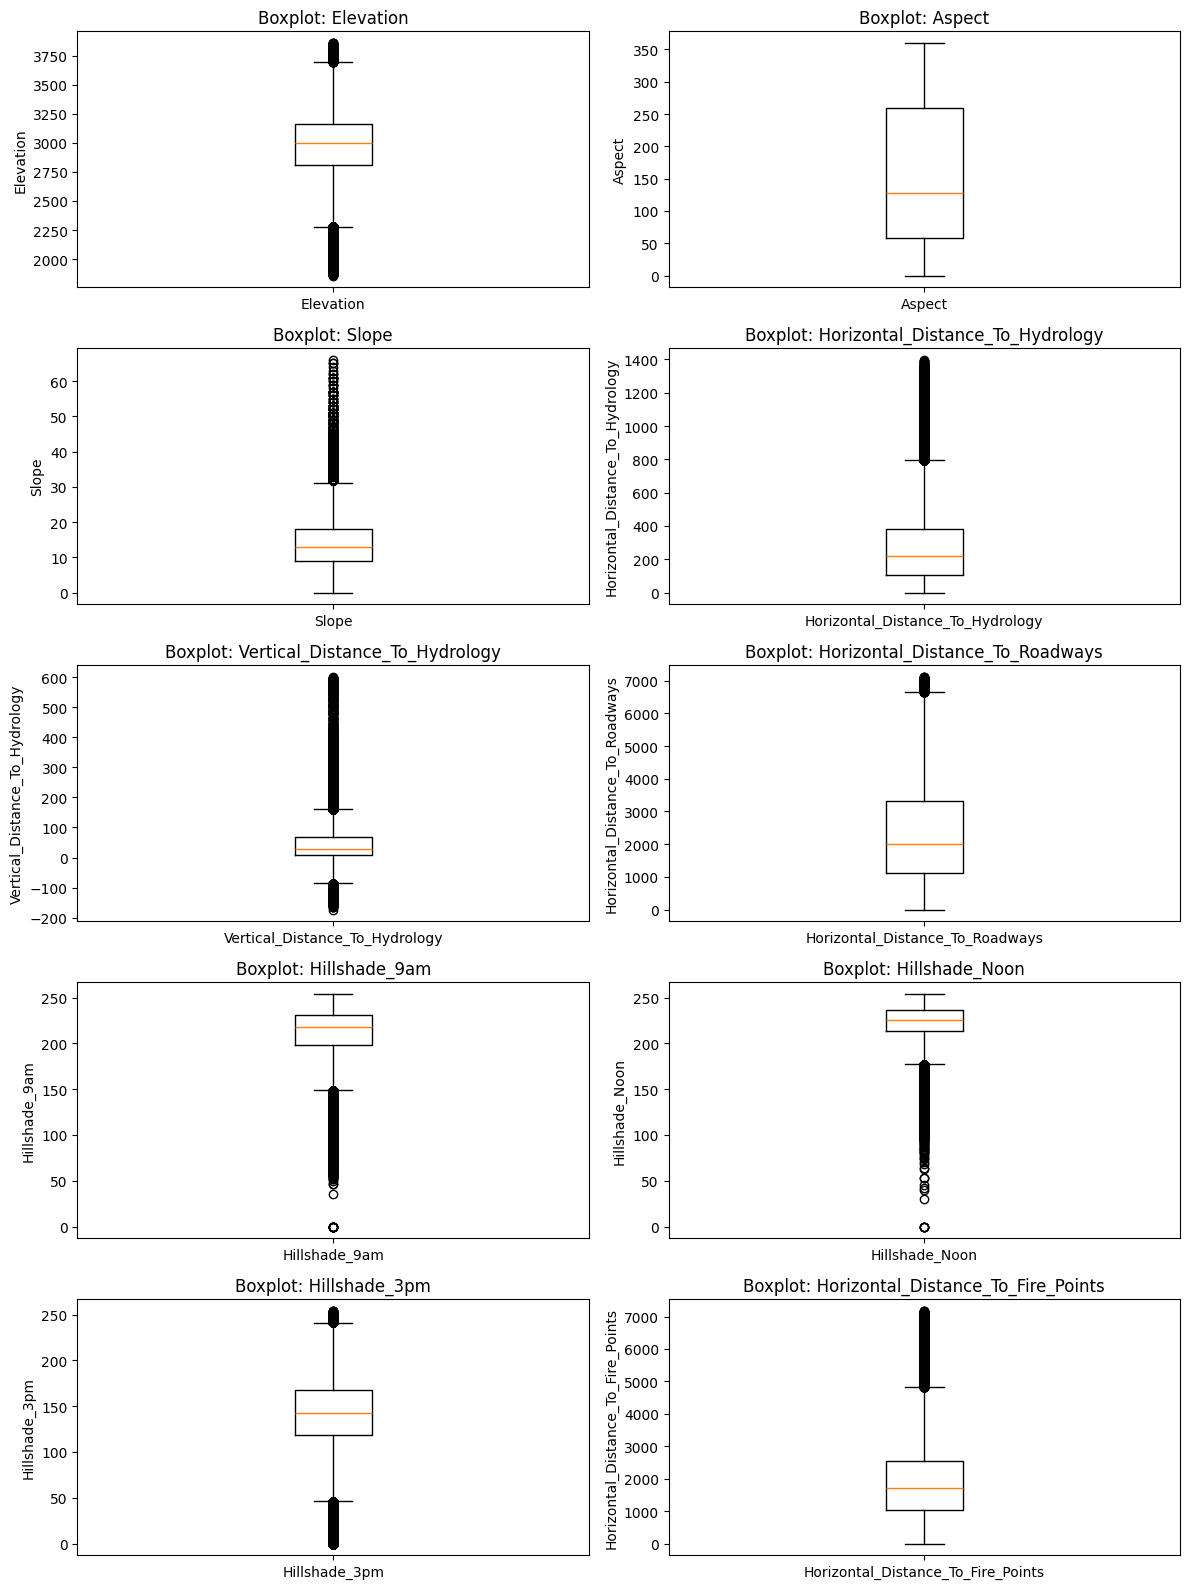

,Variable,IQR-flagged observations,Percentage
0,Elevation,15569,2.68
1,Aspect,0,0.00
2,Slope,15316,2.64
3,Horizontal_Distance_To_Hydrology,14557,2.51
4,Vertical_Distance_To_Hydrology,31463,5.42
5,Horizontal_Distance_To_Roadways,669,0.12
6,Hillshade_9am,17433,3.00
7,Hillshade_Noon,15672,2.70
8,Hillshade_3pm,7832,1.35
9,Horizontal_Distance_To_Fire_Points,31157,5.36


In [8]:
fig, axes = plt.subplots(5, 2, figsize=(12, 16))
axes = axes.ravel()

iqr_flag_summary = []

for ax, col in zip(axes, QUANTITATIVE_COLS):
    ax.boxplot(df[col], vert=True, tick_labels=[col])
    ax.set_title(f"Boxplot: {col}")
    ax.set_ylabel(col)

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_flagged = int(((df[col] < lower) | (df[col] > upper)).sum())
    iqr_flag_summary.append({
        "Variable": col,
        "IQR-flagged observations": n_flagged,
        "Percentage": round(100 * n_flagged / len(df), 2),
    })

plt.tight_layout()
plt.show()

iqr_flag_df = pd.DataFrame(iqr_flag_summary)
display(iqr_flag_df)


**Interpretation.** Separate panels keep small-scale variables (slope, hillshade) readable alongside large-scale distances. Several variables show points beyond the whiskers under the common 1.5×IQR rule—especially `Vertical_Distance_To_Hydrology` and `Horizontal_Distance_To_Fire_Points` (about 5% of rows each), while `Aspect` has none. Boxplot-flagged points are **not** automatically data errors; in terrain and distance data, long tails can be legitimate. Without domain evidence of faulty measurement, these observations are **retained**. No rows are removed.

### 6.5 Target Variable Distribution

Class frequencies for `Cover_Type` on the full dataset.

,Cover_Type,Class name,Frequency,Percentage
0,1,Spruce/Fir,211840,36.461
1,2,Lodgepole Pine,283301,48.760
2,3,Ponderosa Pine,35754,6.154
3,4,Cottonwood/Willow,2747,0.473
4,5,Aspen,9493,1.634
5,6,Douglas-fir,17367,2.989
6,7,Krummholz,20510,3.530


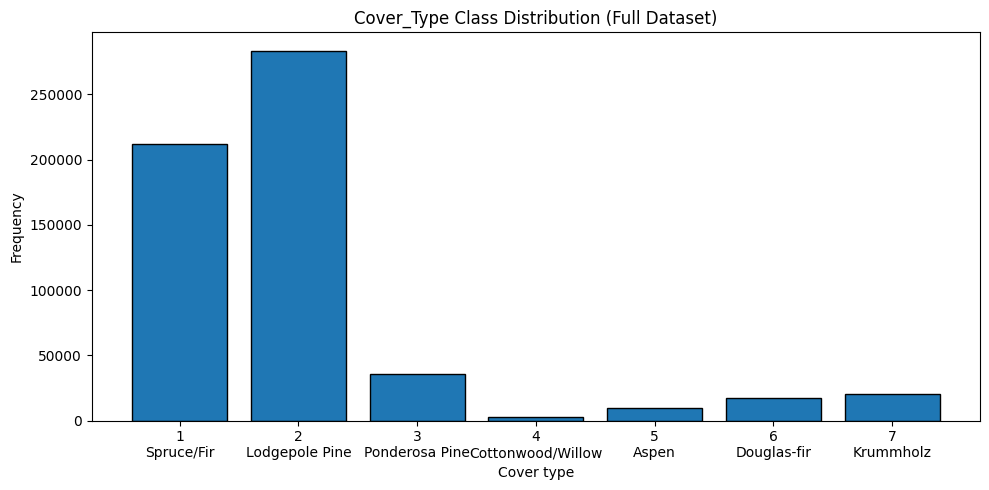

Majority class: 2 (Lodgepole Pine) - 48.760%
Minority class: 4 (Cottonwood/Willow) - 0.473%


In [9]:
COVER_TYPE_NAMES = {
    1: "Spruce/Fir",
    2: "Lodgepole Pine",
    3: "Ponderosa Pine",
    4: "Cottonwood/Willow",
    5: "Aspen",
    6: "Douglas-fir",
    7: "Krummholz",
}

class_counts = df["Cover_Type"].value_counts().sort_index()
class_table = pd.DataFrame({
    "Cover_Type": class_counts.index,
    "Class name": [COVER_TYPE_NAMES[i] for i in class_counts.index],
    "Frequency": class_counts.values,
    "Percentage": (100 * class_counts.values / len(df)).round(3),
})
display(class_table)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    [f"{i}\n{COVER_TYPE_NAMES[i]}" for i in class_table["Cover_Type"]],
    class_table["Frequency"],
    edgecolor="black",
)
ax.set_title("Cover_Type Class Distribution (Full Dataset)")
ax.set_xlabel("Cover type")
ax.set_ylabel("Frequency")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

majority_idx = int(class_table.loc[class_table["Frequency"].idxmax(), "Cover_Type"])
minority_idx = int(class_table.loc[class_table["Frequency"].idxmin(), "Cover_Type"])
print(
    f"Majority class: {majority_idx} ({COVER_TYPE_NAMES[majority_idx]}) - "
    f"{class_table.loc[class_table['Cover_Type']==majority_idx, 'Percentage'].iloc[0]:.3f}%"
)
print(
    f"Minority class: {minority_idx} ({COVER_TYPE_NAMES[minority_idx]}) - "
    f"{class_table.loc[class_table['Cover_Type']==minority_idx, 'Percentage'].iloc[0]:.3f}%"
)


**Interpretation.** The target is strongly imbalanced. **Lodgepole Pine (class 2)** is the majority class (~48.76%), and **Spruce/Fir (class 1)** is also frequent (~36.46%). Together they account for roughly 85% of observations. **Cottonwood/Willow (class 4)** is the minority class (~0.47%). The remaining classes each occupy only a few percent of the data.

This imbalance motivates the approved evaluation design: **stratified** 10-fold cross-validation (to preserve class proportions in each fold) and **macro-averaged** Precision, Recall, and F1 (so rare classes are not ignored by majority-dominated accuracy). No model performance is reported here because modeling has not started.

### 6.6 Wilderness Area Analysis

Each observation has exactly one active wilderness indicator; frequencies therefore describe the geographic composition of the sample.

,Variable,Wilderness area,Frequency,Percentage
0,Wilderness_Area_1,Rawah,260796,44.887
1,Wilderness_Area_2,Neota,29884,5.143
2,Wilderness_Area_3,Comanche Peak,253364,43.607
3,Wilderness_Area_4,Cache la Poudre,36968,6.363


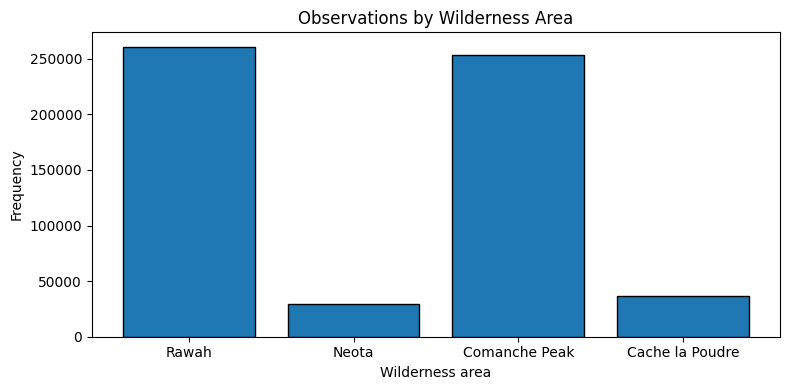

In [10]:
WILDERNESS_NAMES = {
    "Wilderness_Area_1": "Rawah",
    "Wilderness_Area_2": "Neota",
    "Wilderness_Area_3": "Comanche Peak",
    "Wilderness_Area_4": "Cache la Poudre",
}

wilderness_table = pd.DataFrame({
    "Variable": WILDERNESS_COLS,
    "Wilderness area": [WILDERNESS_NAMES[c] for c in WILDERNESS_COLS],
    "Frequency": [int(df[c].sum()) for c in WILDERNESS_COLS],
    "Percentage": [round(100 * df[c].mean(), 3) for c in WILDERNESS_COLS],
})
display(wilderness_table)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(wilderness_table["Wilderness area"], wilderness_table["Frequency"], edgecolor="black")
ax.set_title("Observations by Wilderness Area")
ax.set_xlabel("Wilderness area")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


**Interpretation.** Most observations belong to **Rawah** (`Wilderness_Area_1`, ~44.89%) and **Comanche Peak** (`Wilderness_Area_3`, ~43.61%). **Cache la Poudre** (~6.36%) and **Neota** (~5.14%) contribute fewer cells. This uneven representation is a dataset composition fact relevant for stratified sampling later; no additional geographic causation is inferred beyond the official area designations.

### 6.7 Soil Type Analysis

Frequencies of the 40 soil-type indicators (one active soil type per row). The bar chart is sorted by frequency for readability; original variable names are preserved in the table.

Soil type frequencies (sorted by frequency, descending):


,Variable,Frequency,Percentage
0,Soil_Type_29,115247,19.8356
1,Soil_Type_23,57752,9.9399
2,Soil_Type_32,52519,9.0392
3,Soil_Type_33,45154,7.7716
4,Soil_Type_22,33373,5.7439
5,Soil_Type_10,32634,5.6168
6,Soil_Type_30,30170,5.1927
7,Soil_Type_12,29971,5.1584
8,Soil_Type_31,25666,4.4175
9,Soil_Type_24,21278,3.6622


Soil types with zero observations: None

Most frequent soil types:


,Variable,Frequency,Percentage
0,Soil_Type_29,115247,19.8356
1,Soil_Type_23,57752,9.9399
2,Soil_Type_32,52519,9.0392
3,Soil_Type_33,45154,7.7716
4,Soil_Type_22,33373,5.7439


Least frequent soil types:


,Variable,Frequency,Percentage
35,Soil_Type_37,298,0.0513
36,Soil_Type_8,179,0.0308
37,Soil_Type_36,119,0.0205
38,Soil_Type_7,105,0.0181
39,Soil_Type_15,3,0.0005


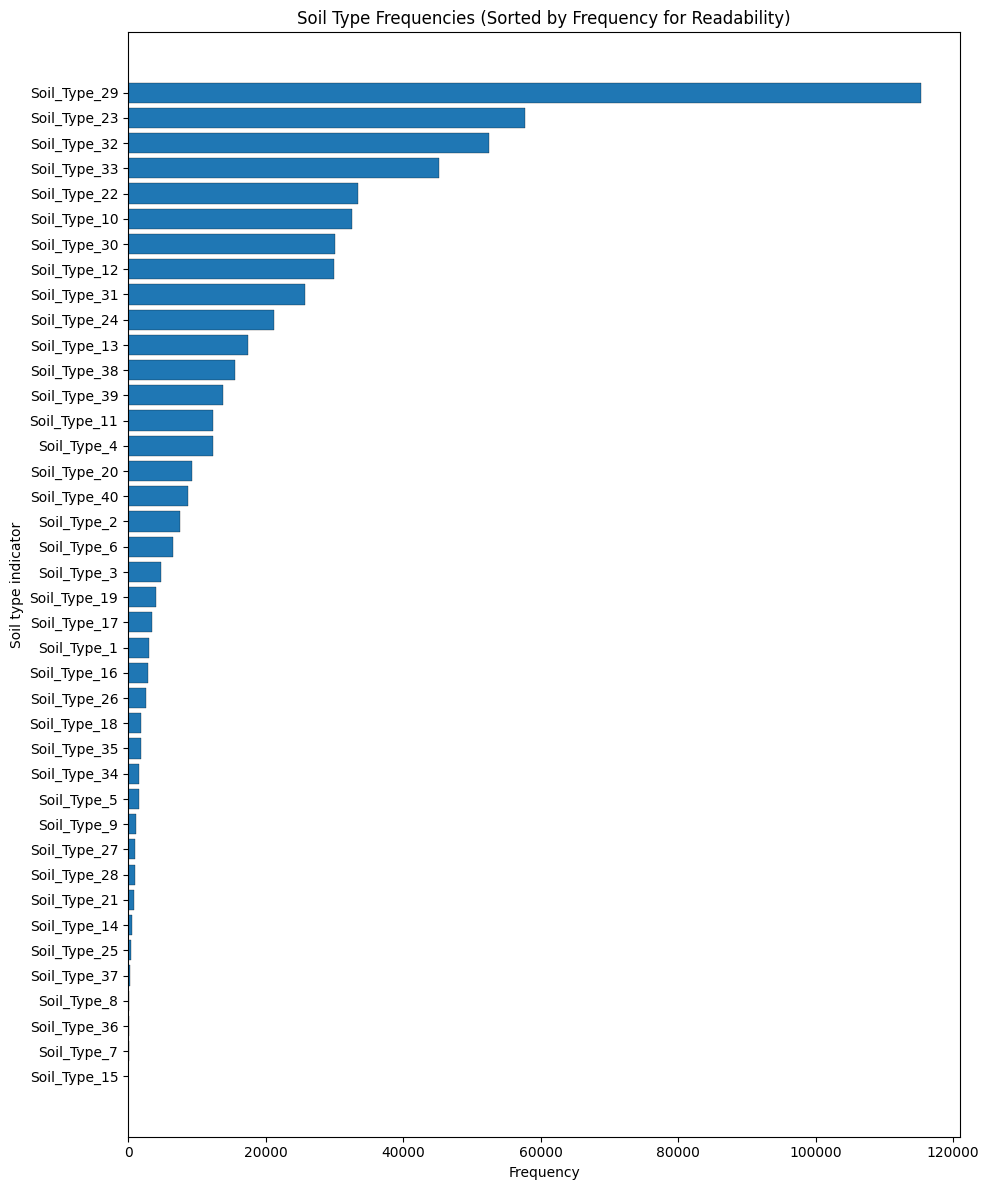

In [11]:
soil_table = pd.DataFrame({
    "Variable": SOIL_COLS,
    "Frequency": [int(df[c].sum()) for c in SOIL_COLS],
    "Percentage": [round(100 * df[c].mean(), 4) for c in SOIL_COLS],
})

soil_table_sorted = soil_table.sort_values("Frequency", ascending=False).reset_index(drop=True)
print("Soil type frequencies (sorted by frequency, descending):")
display(soil_table_sorted)

zero_soils = soil_table.loc[soil_table["Frequency"] == 0, "Variable"].tolist()
print("Soil types with zero observations:", zero_soils if zero_soils else "None")
print("\nMost frequent soil types:")
display(soil_table_sorted.head(5))
print("Least frequent soil types:")
display(soil_table_sorted.tail(5))

fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(
    soil_table_sorted["Variable"][::-1],
    soil_table_sorted["Frequency"][::-1],
    edgecolor="black",
    linewidth=0.2,
)
ax.set_title("Soil Type Frequencies (Sorted by Frequency for Readability)")
ax.set_xlabel("Frequency")
ax.set_ylabel("Soil type indicator")
plt.tight_layout()
plt.show()


**Interpretation.** Soil representation is highly uneven. The most frequent indicators include **`Soil_Type_29`**, **`Soil_Type_23`**, **`Soil_Type_32`**, **`Soil_Type_33`**, and **`Soil_Type_22`**. The rarest observed types include **`Soil_Type_15`** (only 3 observations), followed by other low-count soils such as types 7, 36, 8, and 37. **No soil-type column has zero observations** in this dataset. Rare soils, like rare cover types, reinforce why stratified folds and macro metrics are appropriate for later evaluation.

### 6.8 Correlation Analysis

Correlation is computed among the **ten quantitative variables** only. Including all 44 binary indicators and the integer class label in one 55×55 heatmap would be hard to read and mixes different variable meanings; binary presence indicators are better summarized by frequencies (Sections 6.6–6.7), and `Cover_Type` is a nominal multiclass label rather than a continuous scale for Pearson correlation.

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points
Elevation,1.000,0.016,-0.243,0.306,0.093,0.366,0.112,0.206,0.059,0.148
Aspect,0.016,1.000,0.079,0.017,0.070,0.025,-0.579,0.336,0.647,-0.109
Slope,-0.243,0.079,1.000,-0.011,0.275,-0.216,-0.327,-0.527,-0.176,-0.186
Horizontal_Distance_To_Hydrology,0.306,0.017,-0.011,1.000,0.606,0.072,-0.027,0.047,0.052,0.052
Vertical_Distance_To_Hydrology,0.093,0.070,0.275,0.606,1.000,-0.046,-0.166,-0.111,0.035,-0.070
Horizontal_Distance_To_Roadways,0.366,0.025,-0.216,0.072,-0.046,1.000,0.034,0.189,0.106,0.332
Hillshade_9am,0.112,-0.579,-0.327,-0.027,-0.166,0.034,1.000,0.010,-0.780,0.133
Hillshade_Noon,0.206,0.336,-0.527,0.047,-0.111,0.189,0.010,1.000,0.594,0.057
Hillshade_3pm,0.059,0.647,-0.176,0.052,0.035,0.106,-0.780,0.594,1.000,-0.048
Horizontal_Distance_To_Fire_Points,0.148,-0.109,-0.186,0.052,-0.070,0.332,0.133,0.057,-0.048,1.000


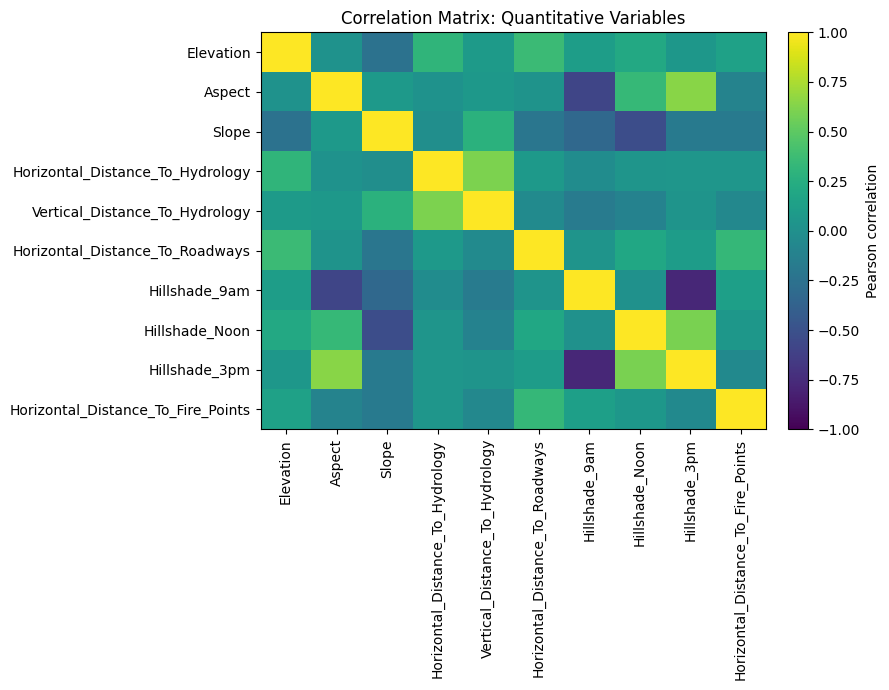

Strongest absolute correlations among quantitative variables:
Hillshade_9am vs Hillshade_3pm: r = -0.7803
Aspect vs Hillshade_3pm: r = 0.6469
Horizontal_Distance_To_Hydrology vs Vertical_Distance_To_Hydrology: r = 0.6062
Hillshade_Noon vs Hillshade_3pm: r = 0.5943
Aspect vs Hillshade_9am: r = -0.5793
Slope vs Hillshade_Noon: r = -0.5269


In [12]:
corr_quant = df[QUANTITATIVE_COLS].corr()
display(corr_quant.round(3))

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_quant, aspect="auto", interpolation="nearest", vmin=-1, vmax=1)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson correlation")
ax.set_title("Correlation Matrix: Quantitative Variables")
ax.set_xticks(range(len(QUANTITATIVE_COLS)))
ax.set_yticks(range(len(QUANTITATIVE_COLS)))
ax.set_xticklabels(QUANTITATIVE_COLS, rotation=90)
ax.set_yticklabels(QUANTITATIVE_COLS)
plt.tight_layout()
plt.show()

corr_pairs = []
for i, a in enumerate(QUANTITATIVE_COLS):
    for j, b in enumerate(QUANTITATIVE_COLS):
        if j <= i:
            continue
        corr_pairs.append((abs(corr_quant.loc[a, b]), corr_quant.loc[a, b], a, b))

corr_pairs.sort(reverse=True)
print("Strongest absolute correlations among quantitative variables:")
for abs_r, r, a, b in corr_pairs[:6]:
    print(f"{a} vs {b}: r = {r:.4f}")


**Interpretation.** The strongest quantitative associations are:

- `Hillshade_9am` and `Hillshade_3pm`: strong **negative** correlation (about −0.78)
- `Aspect` and `Hillshade_3pm`: moderate-to-strong **positive** correlation (about 0.65)
- `Horizontal_Distance_To_Hydrology` and `Vertical_Distance_To_Hydrology`: moderate **positive** correlation (about 0.61)
- `Hillshade_Noon` and `Hillshade_3pm`: moderate **positive** correlation (about 0.59)
- `Aspect` and `Hillshade_9am`: moderate **negative** correlation (about −0.58)
- `Slope` and `Hillshade_Noon`: moderate **negative** correlation (about −0.53)

These coefficients describe linear co-movement among cartographic measures (especially illumination-related hillshade and aspect). They do **not** imply causation.

### 6.9 Duplicate Analysis

Exact duplicate rows are counted on the full dataset. Duplicates are reported only; they are **not** removed.

In [13]:
n_duplicates = int(df.duplicated().sum())
pct_duplicates = 100 * n_duplicates / len(df)

print(f"Exact duplicate rows: {n_duplicates}")
print(f"Percentage of rows that are duplicates of an earlier row: {pct_duplicates:.6f}%")
print(f"Dataset shape remains: {df.shape}")


Exact duplicate rows: 0
Percentage of rows that are duplicates of an earlier row: 0.000000%
Dataset shape remains: (581012, 55)


**Interpretation.** There are **0** exact duplicate rows in the full dataset. Even when duplicates appear in other datasets, identical cartographic attribute vectors alone would not prove that records are erroneous; here, no duplicate-based cleaning is needed or performed. The dataset used for later phases remains unchanged.

### 6.10 EDA Summary

Findings supported by the analyses above:

1. **Completeness:** The full dataset has 581,012 × 55 entries with **no missing values** and structurally valid wilderness/soil indicators.
2. **Scales:** Quantitative predictors span incompatible units and ranges (degrees, 0–255 indices, and meter distances up to thousands). Standardization will be needed later inside modeling pipelines; it was not applied during EDA.
3. **Distributions:** Many distance variables are right-skewed; hillshade and elevation show different concentration patterns. Boxplot whisker flags exist for several variables but are retained as potentially legitimate extremes.
4. **Class imbalance:** Classes 1–2 dominate (~85% combined); class 4 is rare (~0.47%). This supports stratified folds and macro-averaged metrics in the approved evaluation plan.
5. **Wilderness / soil representation:** Rawah and Comanche Peak dominate wilderness membership; soil types are highly uneven, with no empty soil columns but some very rare soils.
6. **Correlations:** The strongest quantitative links involve hillshade/aspect relationships and the two hydrology distances; correlation is not treated as causation.
7. **Duplicates:** No exact duplicate rows were found; no rows were removed.
8. **Preprocessing implications for later phases:** Keep all observations; scale quantitative features inside CV pipelines; preserve class proportions via stratification; evaluate with Macro-Precision, Macro-Recall, and Macro-F1.

No classifier performance is claimed at this stage, and no preprocessing or modeling sample (`N_work`) has been created yet.

## 7. Preprocessing and Modeling Strategy

Before Logistic Regression and SVM are trained, the feature matrix must be prepared in a leakage-safe way.

EDA showed that Covertype has **54 predictors**: **10 quantitative/cartographic variables** with substantially different numerical scales (meters, degrees, 0–255 hillshade indices) and **44 binary indicator variables** (wilderness areas and soil types). Logistic Regression and SVM are sensitive to feature magnitude, so standardization is appropriate for the quantitative block.

Following the professor’s pipeline methodology (`Pipeline` / `ColumnTransformer` with `StandardScaler`), any scaling parameters must be learned **only from training folds** during cross-validation. Fitting a scaler on the full dataset—or on all of `N_work` before splitting folds—would leak information into validation folds. Therefore, the preprocessor is **defined** here but **not fitted** on the full data in this section.

### 7.1 Features and Target

Separate predictors `X` from the target `y = Cover_Type` on the full dataset.

In [14]:
TARGET = "Cover_Type"

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of predictors:", X.shape[1])
print("Cover_Type classes:", sorted(y.unique().tolist()))

assert X.shape == (581012, 54)
assert y.shape == (581012,)
assert set(y.unique()) == {1, 2, 3, 4, 5, 6, 7}
assert int(X.isna().sum().sum()) == 0
assert int(y.isna().sum()) == 0

print("Feature/target separation checks passed.")


X shape: (581012, 54)
y shape: (581012,)
Number of predictors: 54
Cover_Type classes: [1, 2, 3, 4, 5, 6, 7]
Feature/target separation checks passed.


**Interpretation.** `X` contains all 54 predictors and `y` contains the seven `Cover_Type` labels for 581,012 observations. Neither matrix is modified beyond this separation.

### 7.2 Predictor Groups

Explicit group definitions matching the official Covertype documentation.

In [15]:
QUANTITATIVE_COLS = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points",
]

WILDERNESS_COLS = [f"Wilderness_Area_{i}" for i in range(1, 5)]
SOIL_COLS = [f"Soil_Type_{i}" for i in range(1, 41)]
BINARY_COLS = WILDERNESS_COLS + SOIL_COLS

assert len(QUANTITATIVE_COLS) == 10
assert len(BINARY_COLS) == 44
assert len(QUANTITATIVE_COLS) + len(BINARY_COLS) == 54
assert set(QUANTITATIVE_COLS + BINARY_COLS) == set(X.columns)

print("Quantitative predictors (10):", QUANTITATIVE_COLS)
print("Wilderness indicators (4):", WILDERNESS_COLS)
print("Soil indicators (40): count =", len(SOIL_COLS))
print("Binary predictors total:", len(BINARY_COLS))
print("Predictor-group checks passed.")


Quantitative predictors (10): ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']
Wilderness indicators (4): ['Wilderness_Area_1', 'Wilderness_Area_2', 'Wilderness_Area_3', 'Wilderness_Area_4']
Soil indicators (40): count = 40
Binary predictors total: 44
Predictor-group checks passed.


**Interpretation.** The 54 predictors partition cleanly into 10 quantitative cartographic measures and 44 binary indicators (4 wilderness + 40 soil), matching the official dataset structure.

### 7.3 Scaling Strategy

**Professor reference.** In `ML_pipeline_logistic_regression.ipynb`, preprocessing uses `ColumnTransformer` + `StandardScaler` inside a `Pipeline`, so scaling is fitted within the learning workflow rather than on the full table beforehand. That example scaled its numeric feature set (all predictors were numeric).

**Covertype adaptation.** Covertype mixes large-scale cartographic measures with already-coded 0/1 indicators. The approved design therefore:

1. **Standardizes only the 10 quantitative predictors** with `StandardScaler`.
2. **Passes the 44 binary indicators through unchanged**.
3. Applies this transform **inside** the model `Pipeline` during cross-validation (not fitted here on the full dataset).

Binary 0/1 columns are preserved because they already encode presence/absence on a common scale; standardizing them is unnecessary for this project and would distort their indicator interpretation without improving methodological clarity.

This remains compatible with the professor’s tools (`ColumnTransformer`, `StandardScaler`, `Pipeline`) while respecting Covertype’s mixed feature types. No imputation step is required (EDA found no missing values).

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, train_test_split

# Preprocessor definition only — NOT fitted on the full dataset in this phase.
preprocess = ColumnTransformer(
    transformers=[
        ("quant", StandardScaler(), QUANTITATIVE_COLS),
        ("binary", "passthrough", BINARY_COLS),
    ]
)

print("Preprocessor defined (not fitted):")
print(preprocess)
print("\nNote: fitting will occur later only inside training folds via a model Pipeline.")


Preprocessor defined (not fitted):
ColumnTransformer(transformers=[('quant', StandardScaler(),
                                 ['Elevation', 'Aspect', 'Slope',
                                  'Horizontal_Distance_To_Hydrology',
                                  'Vertical_Distance_To_Hydrology',
                                  'Horizontal_Distance_To_Roadways',
                                  'Hillshade_9am', 'Hillshade_Noon',
                                  'Hillshade_3pm',
                                  'Horizontal_Distance_To_Fire_Points']),
                                ('binary', 'passthrough',
                                 ['Wilderness_Area_1', 'Wilderness_Area_2',
                                  'Wilder...
                                  'Soil_Type_1', 'Soil_Type_2', 'Soil_Type_3',
                                  'Soil_Type_4', 'Soil_Type_5', 'Soil_Type_6',
                                  'Soil_Type_7', 'Soil_Type_8', 'Soil_Type_9',
                      

**Interpretation.** `preprocess` is constructed but **not fitted**. When modeling begins, it will be placed as the first step of each estimator `Pipeline` so that `StandardScaler` parameters are estimated from each training fold only.

### 7.4 Reproducible Stratified Modeling Sample

Create the approved working set (`N_work = 25,000`, `random_state = 42`) with stratified sampling so that `Cover_Type` proportions closely match the full dataset. The sample exists only in memory.

In [17]:
N_WORK = 25_000
assert RANDOM_STATE == 42

X_work, _, y_work, _ = train_test_split(
    X,
    y,
    train_size=N_WORK,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Keep a combined working frame for transparent verification tables
df_work = X_work.copy()
df_work[TARGET] = y_work.values

print("X_work shape:", X_work.shape)
print("y_work shape:", y_work.shape)
print("Working sample classes:", sorted(y_work.unique().tolist()))
print("Full X shape unchanged:", X.shape)
print("Full y shape unchanged:", y.shape)


X_work shape: (25000, 54)
y_work shape: (25000,)
Working sample classes: [1, 2, 3, 4, 5, 6, 7]
Full X shape unchanged: (581012, 54)
Full y shape unchanged: (581012,)


**Interpretation.** A stratified draw of 25,000 observations was obtained with `train_test_split(..., stratify=y, random_state=42)`. The full matrices `X` and `y` remain at 581,012 rows and are not overwritten.

### 7.5 Working Sample Verification

In [18]:
assert X_work.shape == (N_WORK, 54)
assert y_work.shape == (N_WORK,)
assert set(y_work.unique()) == {1, 2, 3, 4, 5, 6, 7}
assert int(X_work.isna().sum().sum()) == 0
assert int(y_work.isna().sum()) == 0
assert X.shape[0] == 581012
assert y.shape[0] == 581012

full_counts = y.value_counts().sort_index()
work_counts = y_work.value_counts().sort_index()

stratification_table = pd.DataFrame({
    "Cover_Type": full_counts.index,
    "Class name": [COVER_TYPE_NAMES[i] for i in full_counts.index],
    "Full count": full_counts.values,
    "Full %": (100 * full_counts.values / len(y)).round(3),
    "Working count": [int(work_counts.get(i, 0)) for i in full_counts.index],
    "Working %": (100 * np.array([work_counts.get(i, 0) for i in full_counts.index]) / N_WORK).round(3),
})
stratification_table["Percentage-point difference"] = (
    stratification_table["Working %"] - stratification_table["Full %"]
).round(3)

display(stratification_table)

max_pp_diff = float(stratification_table["Percentage-point difference"].abs().max())
print(f"Maximum absolute percentage-point difference: {max_pp_diff:.3f}")
print("Working-sample verification checks passed.")


,Cover_Type,Class name,Full count,Full %,Working count,Working %,Percentage-point difference
0,1,Spruce/Fir,211840,36.461,9115,36.460,-0.001
1,2,Lodgepole Pine,283301,48.760,12190,48.760,0.000
2,3,Ponderosa Pine,35754,6.154,1538,6.152,-0.002
3,4,Cottonwood/Willow,2747,0.473,118,0.472,-0.001
4,5,Aspen,9493,1.634,409,1.636,0.002
5,6,Douglas-fir,17367,2.989,747,2.988,-0.001
6,7,Krummholz,20510,3.530,883,3.532,0.002


Maximum absolute percentage-point difference: 0.002
Working-sample verification checks passed.


**Interpretation.** The working sample has exactly 25,000 rows, 54 predictors, all seven classes, and no missing values, while the full dataset remains 581,012 observations. Class percentages in `N_work` stay very close to the full-data percentages (percentage-point gaps are small), confirming that stratification preserved the original `Cover_Type` distribution for fair later comparison of Logistic Regression and SVM.

### 7.6 Expected Minority-Class Representation in 10 Folds

Under stratified 10-fold CV, each validation fold receives about one-tenth of each class count in `N_work`.

In [19]:
minority_class = int(work_counts.idxmin())
minority_count_work = int(work_counts.loc[minority_class])
expected_per_val_fold = minority_count_work / 10

print(f"Minority class in N_work: {minority_class} ({COVER_TYPE_NAMES[minority_class]})")
print(f"Minority-class count in N_work: {minority_count_work}")
print(f"Expected minority observations per validation fold (10-fold stratified): {expected_per_val_fold:.2f}")

print("\nAll class counts in N_work and expected per validation fold:")
fold_expect = pd.DataFrame({
    "Cover_Type": work_counts.index,
    "Class name": [COVER_TYPE_NAMES[i] for i in work_counts.index],
    "Count in N_work": work_counts.values,
    "Expected count per validation fold": (work_counts.values / 10).round(2),
})
display(fold_expect)


Minority class in N_work: 4 (Cottonwood/Willow)
Minority-class count in N_work: 118
Expected minority observations per validation fold (10-fold stratified): 11.80

All class counts in N_work and expected per validation fold:


,Cover_Type,Class name,Count in N_work,Expected count per validation fold
0,1,Spruce/Fir,9115,911.5
1,2,Lodgepole Pine,12190,1219.0
2,3,Ponderosa Pine,1538,153.8
3,4,Cottonwood/Willow,118,11.8
4,5,Aspen,409,40.9
5,6,Douglas-fir,747,74.7
6,7,Krummholz,883,88.3


**Interpretation.** Because Macro-Precision, Macro-Recall, and Macro-F1 average per-class scores, every class—especially the minority class—must appear in validation folds. With the actual `N_work` minority count above, stratified 10-fold CV yields on the order of **~12** minority-class validation cases per fold (exact value printed above). That is enough to compute class-wise metrics without empty minority validation folds, which supports reliable macro-averaged evaluation.

### 7.7 Cross-Validation Protocol

Define the approved cross-validation splitter. It is **not executed** in this phase.

In [20]:
cv_10 = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE,
)

print(cv_10)
print("Cross-validation object defined only — no folds iterated and no model trained.")


StratifiedKFold(n_splits=10, random_state=42, shuffle=True)
Cross-validation object defined only — no folds iterated and no model trained.


**Interpretation.**

- **10 folds** satisfy the Project 1 requirement and match the professor’s SVM practice fold count.
- **Stratification** preserves class proportions in each fold, which is essential under Covertype’s imbalance.
- **`shuffle=True` with `random_state=42`** makes fold assignment reproducible across runs.

No `cross_validate`, `GridSearchCV`, or estimator fitting is performed here.

### 7.8 Evaluation Metrics

Macro-averaged metrics for the seven-class problem (defined for later use; not computed on predictions yet).

In [21]:
scoring = {
    "macro_precision": "precision_macro",
    "macro_recall": "recall_macro",
    "macro_f1": "f1_macro",
}

PRIMARY_METRIC = "macro_f1"

print("Scoring dictionary for later cross-validation:")
print(scoring)
print(f"Primary model-selection metric: {PRIMARY_METRIC}")


Scoring dictionary for later cross-validation:
{'macro_precision': 'precision_macro', 'macro_recall': 'recall_macro', 'macro_f1': 'f1_macro'}
Primary model-selection metric: macro_f1


**Interpretation.**

- **Macro-Precision** averages per-class precision and emphasizes false positives equally across classes.
- **Macro-Recall** averages per-class recall and emphasizes false negatives equally across classes.
- **Macro-F1** is the harmonic-style aggregate of precision/recall information at the macro level and balances both concerns across classes.

Macro averaging is appropriate because classes are mutually exclusive and highly imbalanced: accuracy or micro averages would be dominated by classes 1–2. Per the approved methodology, **Macro-F1** is the primary criterion for selecting the best hyperparameter configuration; Macro-Precision and Macro-Recall are always reported as well.

### 7.9 Modeling Protocol Summary

| Scope | Content |
|-------|---------|
| **Full dataset (581,012)** | Dataset description, verification, and EDA |
| **Working sample (`N_work` = 25,000)** | Logistic Regression, SVM, hyperparameter evaluation, stratified 10-fold CV, and the primary LR vs SVM comparison |
| **Preprocessing** | Learned only inside training folds; **quantitative** variables standardized with `StandardScaler`; **binary** indicators passed through unchanged via `ColumnTransformer` |
| **Metrics** | Macro-Precision, Macro-Recall, Macro-F1 (mean ± std across folds); **Macro-F1** for model selection |
| **Reproducibility** | `RANDOM_STATE = 42`; `cv_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)` |
| **Disclosure** | Nonlinear SVM / primary ML comparison uses the stratified sample because a full-data nonlinear `SVC` grid with 10-fold CV on 581,012 rows is computationally impractical |

No model results are reported here because no estimator has been trained yet.

## 8. Logistic Regression

Logistic Regression is used here as a **supervised multiclass classifier** for the seven forest cover types. In scikit-learn, `LogisticRegression` extends the binary logistic model to multiple classes (multinomial / one-vs-rest formulations depending on solver settings) and assigns each observation to a predicted `Cover_Type`.

EDA showed that the ten quantitative predictors have incompatible numerical scales. Because Logistic Regression is sensitive to feature magnitude, those variables are standardized **inside** the modeling `Pipeline`, using the Phase 4 `ColumnTransformer`, so scaling parameters are estimated only on each training fold and data leakage into validation folds is avoided.

This section evaluates Logistic Regression on the approved working sample (`N_work = 25,000`) with stratified 10-fold cross-validation. No SVM is trained here.

### 8.1 Logistic Regression Pipeline

The pipeline reuses the approved `preprocess` transformer and appends `LogisticRegression`.

**Implementation choices (sklearn 1.x, verified for this environment):**
- Solver: `lbfgs` (supports multiclass logistic regression and `random_state`)
- `max_iter=2000` to reduce convergence failures on 25,000 × 54 data
- `random_state=RANDOM_STATE` (42)
- Default L2 penalty with `lbfgs` (compatible solver/penalty pair)

The pipeline is defined below but is **not** fitted on all of `X_work` outside cross-validation in this subsection.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import ParameterGrid, cross_validate, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import time
import warnings

logreg_base = LogisticRegression(
    solver="lbfgs",
    max_iter=2000,
    random_state=RANDOM_STATE,
)

logreg_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("logreg", logreg_base),
    ]
)

print(logreg_pipeline)
print("\nPipeline defined for cross-validation. No fit on the full working sample yet.")


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('quant', StandardScaler(),
                                                  ['Elevation', 'Aspect',
                                                   'Slope',
                                                   'Horizontal_Distance_To_Hydrology',
                                                   'Vertical_Distance_To_Hydrology',
                                                   'Horizontal_Distance_To_Roadways',
                                                   'Hillshade_9am',
                                                   'Hillshade_Noon',
                                                   'Hillshade_3pm',
                                                   'Horizontal_Distance_To_Fire_Points']),
                                                 ('binary', 'passthrough',
                                                  ['Wilderness_Area_...
                                                   'Soil_

### 8.2 Hyperparameter Grid

A small grid is used, consistent with course practice (vary regularization strength) and computational feasibility.

**Grid:**
- `C ∈ {0.01, 0.1, 1, 10}` — inverse regularization strength (larger `C` → weaker L2 regularization)
- `class_weight ∈ {None, "balanced"}` — included because:
  1. the professor’s logistic pipeline example uses `class_weight="balanced"`, and
  2. Covertype is severely imbalanced (minority class ≈ 0.47%)

This yields **8 configurations**. No incompatible solver/penalty pairs are introduced.

In [23]:
logreg_param_grid = {
    "logreg__C": [0.01, 0.1, 1, 10],
    "logreg__class_weight": [None, "balanced"],
}

logreg_configs = list(ParameterGrid(logreg_param_grid))
print(f"Number of Logistic Regression configurations: {len(logreg_configs)}")
for i, cfg in enumerate(logreg_configs, start=1):
    c_val = cfg["logreg__C"]
    cw_val = cfg["logreg__class_weight"]
    print(f"{i:02d}. C={c_val}, class_weight={cw_val}")


Number of Logistic Regression configurations: 8
01. C=0.01, class_weight=None
02. C=0.01, class_weight=balanced
03. C=0.1, class_weight=None
04. C=0.1, class_weight=balanced
05. C=1, class_weight=None
06. C=1, class_weight=balanced
07. C=10, class_weight=None
08. C=10, class_weight=balanced


### 8.3 10-Fold Hyperparameter Evaluation

Every configuration is evaluated with the **same** `X_work`, `y_work`, `cv_10`, preprocessing pipeline, and scoring dictionary (`precision_macro`, `recall_macro`, `f1_macro`). Results are aggregated as mean ± std across the 10 folds (professor-style reporting). Nested CV is not used.

In [24]:
logreg_rows = []
logreg_t0 = time.time()

with warnings.catch_warnings(record=True) as logreg_warning_list:
    warnings.simplefilter("always")

    for cfg in logreg_configs:
        pipe = Pipeline(
            steps=[
                ("preprocess", preprocess),
                (
                    "logreg",
                    LogisticRegression(
                        solver="lbfgs",
                        max_iter=2000,
                        random_state=RANDOM_STATE,
                        C=cfg["logreg__C"],
                        class_weight=cfg["logreg__class_weight"],
                    ),
                ),
            ]
        )

        cv_res = cross_validate(
            pipe,
            X_work,
            y_work,
            cv=cv_10,
            scoring=scoring,
            return_train_score=False,
            n_jobs=None,
        )

        logreg_rows.append({
            "C": cfg["logreg__C"],
            "class_weight": cfg["logreg__class_weight"],
            "Mean Macro-Precision": cv_res["test_macro_precision"].mean(),
            "Std Macro-Precision": cv_res["test_macro_precision"].std(),
            "Mean Macro-Recall": cv_res["test_macro_recall"].mean(),
            "Std Macro-Recall": cv_res["test_macro_recall"].std(),
            "Mean Macro-F1": cv_res["test_macro_f1"].mean(),
            "Std Macro-F1": cv_res["test_macro_f1"].std(),
            "Mean fit time (s)": cv_res["fit_time"].mean(),
            "Total fit time (s)": cv_res["fit_time"].sum(),
        })

logreg_elapsed = time.time() - logreg_t0

logreg_results = pd.DataFrame(logreg_rows)
logreg_results["class_weight"] = logreg_results["class_weight"].apply(
    lambda x: "None" if x is None else x
)

print(f"Configurations × folds = {len(logreg_configs)} × 10 = {len(logreg_configs) * 10} fits")
print(f"Wall-clock time for LR grid CV: {logreg_elapsed:.2f} s")
print(f"Captured warnings during LR grid: {len(logreg_warning_list)}")

# Summarize warning types (do not hide them)
warn_types = {}
for w in logreg_warning_list:
    name = w.category.__name__
    warn_types[name] = warn_types.get(name, 0) + 1
print("Warning counts by type:", warn_types)


Configurations × folds = 8 × 10 = 80 fits
Wall-clock time for LR grid CV: 87.57 s
Captured warnings during LR grid: 36
Warning counts by type: {'UndefinedMetricWarning': 36}


### 8.4 Logistic Regression Results

Configurations are ranked by **Mean Macro-F1** (primary selection metric).

In [25]:
logreg_results_sorted = logreg_results.sort_values(
    "Mean Macro-F1", ascending=False
).reset_index(drop=True)

display(logreg_results_sorted.round(4))

best_logreg = logreg_results_sorted.iloc[0]
best_logreg_C = float(best_logreg["C"])
best_logreg_cw = None if best_logreg["class_weight"] == "None" else best_logreg["class_weight"]

print("\nBest Logistic Regression configuration (by Mean Macro-F1):")
print(f"  C = {best_logreg_C}")
print(f"  class_weight = {best_logreg['class_weight']}")
print(
    f"  Mean Macro-Precision = {best_logreg['Mean Macro-Precision']:.4f} "
    f"+/- {best_logreg['Std Macro-Precision']:.4f}"
)
print(
    f"  Mean Macro-Recall = {best_logreg['Mean Macro-Recall']:.4f} "
    f"+/- {best_logreg['Std Macro-Recall']:.4f}"
)
print(
    f"  Mean Macro-F1 = {best_logreg['Mean Macro-F1']:.4f} "
    f"+/- {best_logreg['Std Macro-F1']:.4f}"
)
print(
    f"  Mean fit time per fold = {best_logreg['Mean fit time (s)']:.4f} s; "
    f"total fit time for this config = {best_logreg['Total fit time (s)']:.2f} s"
)


,C,class_weight,Mean Macro-Precision,Std Macro-Precision,Mean Macro-Recall,Std Macro-Recall,Mean Macro-F1,Std Macro-F1,Mean fit time (s),Total fit time (s)
0,10.00,None,0.5749,0.0506,0.5042,0.0305,0.5213,0.0320,1.5795,15.7948
1,1.00,None,0.5846,0.0436,0.4958,0.0242,0.5159,0.0260,1.3651,13.6512
2,10.00,balanced,0.4683,0.0128,0.6968,0.0232,0.5012,0.0154,1.6454,16.4541
3,1.00,balanced,0.4684,0.0124,0.6960,0.0240,0.5006,0.0150,1.6288,16.2883
4,0.10,balanced,0.4628,0.0134,0.6896,0.0242,0.4916,0.0149,0.8456,8.4556
5,0.10,None,0.5611,0.0486,0.4559,0.0211,0.4754,0.0262,0.7658,7.6575
6,0.01,balanced,0.4442,0.0100,0.6728,0.0184,0.4639,0.0105,0.4248,4.2484
7,0.01,None,0.4644,0.0196,0.3573,0.0117,0.3619,0.0142,0.3936,3.9362



Best Logistic Regression configuration (by Mean Macro-F1):
  C = 10.0
  class_weight = None
  Mean Macro-Precision = 0.5749 +/- 0.0506
  Mean Macro-Recall = 0.5042 +/- 0.0305
  Mean Macro-F1 = 0.5213 +/- 0.0320
  Mean fit time per fold = 1.5795 s; total fit time for this config = 15.79 s


**Interpretation of the selected metrics.** For the best configuration in the table above, Macro-Precision, Macro-Recall, and Macro-F1 are averages of the seven per-class scores, so each cover type contributes equally regardless of frequency. Macro-Recall is **not** the share of all 25,000 cells classified correctly, and Macro-Precision is **not** overall accuracy. Instead, they summarize how well the classifier balances false positives and false negatives **across classes**, which is appropriate under imbalance.

### 8.5 Metric Interpretation

Using the ranked table:

- The best Mean Macro-F1 configuration is **`C = 10`** with **`class_weight = None`**.
- Its Mean Macro-Precision is moderate (about **0.57**), Mean Macro-Recall is about **0.50**, and Mean Macro-F1 is about **0.52**, with fold-to-fold standard deviations on the order of **0.03–0.05**.
- These values indicate only moderate average per-class performance: some classes are learned more reliably than others, which the per-class diagnostic below examines.

No claim is made about SVM yet.

### 8.6 Hyperparameter Analysis

Patterns visible in the results table:

- **Effect of `C`:** With `class_weight=None`, Macro-F1 rises from the most regularized setting (`C=0.01`) to weaker regularization (`C=10`). The gain from `C=1` to `C=10` is small, so the best configuration is only **slightly** ahead of the next-best unweighted model.
- **Effect of `class_weight`:** `"balanced"` substantially **increases Macro-Recall** (near ~0.69–0.70) but **lowers Macro-Precision** (near ~0.46–0.47), yielding Macro-F1 values slightly below the best unweighted models. Balancing helps rare-class recall on average, but hurts precision enough that Macro-F1 does not win under the approved selection rule.
- **Warnings:** Some folds/configs trigger `UndefinedMetricWarning` when a class receives no predicted labels in a fold (precision undefined for that class and treated as 0 in the macro average). This is especially informative for rare classes and is reported rather than suppressed.
- No unresolved **convergence** warnings were observed with `max_iter=2000` and `lbfgs` in the pilot/execution setup.

### 8.7 Per-Class Diagnostic for the Selected Configuration

Out-of-fold predictions are generated with the **same** stratified 10-fold splits: each working-sample observation is predicted only when held out. These diagnostics are secondary to the official macro metrics from Section 8.4.

Out-of-fold classification report (selected Logistic Regression):
                   precision    recall  f1-score   support

       Spruce/Fir      0.714     0.701     0.707      9115
   Lodgepole Pine      0.750     0.803     0.775     12190
   Ponderosa Pine      0.678     0.791     0.730      1538
Cottonwood/Willow      0.561     0.390     0.460       118
            Aspen      0.500     0.002     0.005       409
      Douglas-fir      0.463     0.258     0.332       747
        Krummholz      0.731     0.586     0.650       883

         accuracy                          0.726     25000
        macro avg      0.628     0.504     0.523     25000
     weighted avg      0.718     0.726     0.716     25000

Confusion matrix counts:
[[6390 2534    4    0    0    3  184]
 [2204 9783  123    0    0   74    6]
 [   0  154 1217   33    1  133    0]
 [   0    0   62   46    0   10    0]
 [   0  391   13    0    1    4    0]
 [   0  175  376    3    0  193    0]
 [ 356   10    0    0    0   

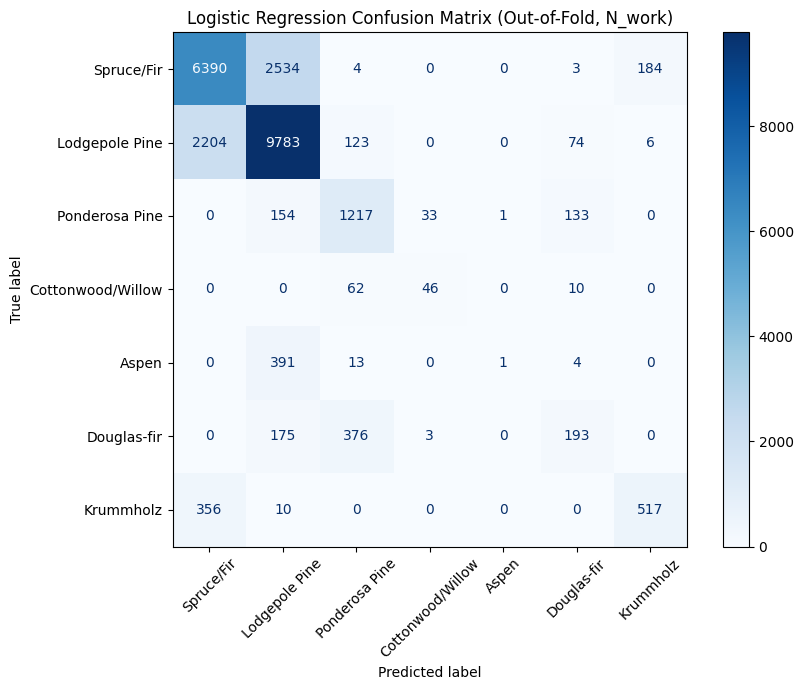

In [26]:
best_logreg_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "logreg",
            LogisticRegression(
                solver="lbfgs",
                max_iter=2000,
                random_state=RANDOM_STATE,
                C=best_logreg_C,
                class_weight=best_logreg_cw,
            ),
        ),
    ]
)

y_work_oof_logreg = cross_val_predict(
    best_logreg_pipeline,
    X_work,
    y_work,
    cv=cv_10,
)

assert len(y_work_oof_logreg) == len(y_work) == N_WORK

class_labels = [1, 2, 3, 4, 5, 6, 7]
target_names = [COVER_TYPE_NAMES[i] for i in class_labels]

print("Out-of-fold classification report (selected Logistic Regression):")
print(
    classification_report(
        y_work,
        y_work_oof_logreg,
        labels=class_labels,
        target_names=target_names,
        digits=3,
        zero_division=0,
    )
)

cm_logreg = confusion_matrix(y_work, y_work_oof_logreg, labels=class_labels)
print("Confusion matrix counts:")
print(cm_logreg)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logreg,
    display_labels=target_names,
)
disp.plot(ax=ax, cmap="Blues", colorbar=True, xticks_rotation=45)
ax.set_title("Logistic Regression Confusion Matrix (Out-of-Fold, N_work)")
plt.tight_layout()
plt.show()


**Per-class diagnostic interpretation (selected model).** Official selection still uses Mean Macro-F1 from Section 8.4. The out-of-fold report shows:

- **Majority classes** (Spruce/Fir, Lodgepole Pine) have relatively higher precision/recall/F1 and large support.
- **Ponderosa Pine** also shows comparatively strong per-class scores.
- **Cottonwood/Willow** (minority) has moderate precision but lower recall.
- **Aspen** is the weakest class under this configuration (very low recall), which pulls down macro averages and helps explain why Macro-F1 remains only moderate.
- **Douglas-fir** shows limited recall relative to the majority classes.

Confusion is concentrated among ecologically/cartographically similar or frequent classes; rare classes are under-predicted more often. These diagnostics motivate reporting macro metrics rather than accuracy alone.

### 8.8 Logistic Regression Findings

Summary of the Logistic Regression experiment on the approved working sample:

| Item | Result |
|------|--------|
| Observations | 25,000 (`N_work`) |
| Protocol | Stratified 10-fold CV (`cv_10`) |
| Configurations evaluated | 8 (`C` × `class_weight`) |
| Total fits | 80 |
| Best hyperparameters | `C=10`, `class_weight=None` |
| Best Mean Macro-Precision | ≈ 0.575 ± 0.051 |
| Best Mean Macro-Recall | ≈ 0.504 ± 0.030 |
| Best Mean Macro-F1 | ≈ 0.521 ± 0.032 |
| Runtime | Grid CV wall-clock on the order of ~1–2 minutes in this environment; best-config total fit time ≈ 16 s across 10 folds |
| Per-class note | Aspen (class 5) is poorly recalled; majority classes are stronger |
| Technical notes | `UndefinedMetricWarning` when a class is never predicted in a fold; no unresolved convergence with `max_iter=2000` |

SVM has **not** been trained yet, so no final model comparison or project winner is declared.

## 9. Support Vector Machine

Support Vector Machines (SVM) are supervised classifiers that learn decision boundaries with a **maximum-margin** emphasis. With a **kernel**, the method can form nonlinear boundaries in the original feature space without explicitly mapping every point.

This project is a **seven-class** forest-cover problem. `sklearn.svm.SVC` handles multiclass classification internally (one-vs-one by default). Because quantitative predictors have very different scales, the Phase 4 `ColumnTransformer` remains the first pipeline step so standardization is learned **only on training folds**.

Official SVM evaluation uses the same `X_work` / `y_work` (`N_work = 25,000`) and `cv_10` as Logistic Regression. The full 581,012-row dataset is **not** used for SVM training here, for computational feasibility (as discussed in the course SVM practice on computational cost).

### 9.1 SVM Pipeline

Pipeline structure matches Logistic Regression: approved `preprocess` + `SVC`. Probability estimates are disabled (`probability=False`, the default) because they are not required and would increase cost.

In [27]:
from sklearn.svm import SVC

svm_pipeline_template = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("svc", SVC()),
    ]
)

print(svm_pipeline_template)
print("SVM pipeline template defined (not fitted on all of X_work outside CV).")


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('quant', StandardScaler(),
                                                  ['Elevation', 'Aspect',
                                                   'Slope',
                                                   'Horizontal_Distance_To_Hydrology',
                                                   'Vertical_Distance_To_Hydrology',
                                                   'Horizontal_Distance_To_Roadways',
                                                   'Hillshade_9am',
                                                   'Hillshade_Noon',
                                                   'Hillshade_3pm',
                                                   'Horizontal_Distance_To_Fire_Points']),
                                                 ('binary', 'passthrough',
                                                  ['Wilderness_Area_...
                                                   'Soil_

### 9.2 Runtime Feasibility Check

Before the official grid, a **timing pilot** estimates cost on one stratified fold of `N_work` (train ≈ 22,500 / validation ≈ 2,500). Pilot metrics are **not** official project results.

In [28]:
import time

# One fold only for timing (same cv_10 object, first split)
_pilot_train_idx, _pilot_test_idx = next(iter(cv_10.split(X_work, y_work)))
X_pilot_tr = X_work.iloc[_pilot_train_idx]
X_pilot_te = X_work.iloc[_pilot_test_idx]
y_pilot_tr = y_work.iloc[_pilot_train_idx]
y_pilot_te = y_work.iloc[_pilot_test_idx]

svm_pilot_candidates = [
    {"kernel": "linear", "C": 1.0},
    {"kernel": "rbf", "C": 1.0, "gamma": "scale"},
    {"kernel": "rbf", "C": 1.0, "gamma": 0.01},
    {"kernel": "poly", "C": 1.0, "degree": 2, "gamma": "scale"},
    {"kernel": "poly", "C": 1.0, "degree": 3, "gamma": "scale"},
]

print(f"Pilot fold sizes: train={len(_pilot_train_idx)}, test={len(_pilot_test_idx)}")
print("Timing one fold fit+predict per candidate (NOT official metrics):\n")

svm_pilot_rows = []
for params in svm_pilot_candidates:
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("svc", SVC(**params)),
    ])
    t0 = time.time()
    pipe.fit(X_pilot_tr, y_pilot_tr)
    _ = pipe.predict(X_pilot_te)
    elapsed = time.time() - t0
    svm_pilot_rows.append({**params, "one_fold_seconds": round(elapsed, 2)})
    print(params, f"-> {elapsed:.2f} s")

svm_pilot_df = pd.DataFrame(svm_pilot_rows)
display(svm_pilot_df)

_avg_pilot = float(svm_pilot_df["one_fold_seconds"].mean())
print(f"\nMean pilot one-fold time: {_avg_pilot:.2f} s")
print("Rough full-grid extrapolation uses this mean later after the final grid size is fixed.")


Pilot fold sizes: train=22500, test=2500
Timing one fold fit+predict per candidate (NOT official metrics):



{'kernel': 'linear', 'C': 1.0} -> 19.40 s


{'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'} -> 20.29 s


{'kernel': 'rbf', 'C': 1.0, 'gamma': 0.01} -> 22.58 s


{'kernel': 'poly', 'C': 1.0, 'degree': 2, 'gamma': 'scale'} -> 16.11 s


{'kernel': 'poly', 'C': 1.0, 'degree': 3, 'gamma': 'scale'} -> 14.25 s


,kernel,C,one_fold_seconds,gamma,degree
0,linear,1.0,19.40,NaN,NaN
1,rbf,1.0,20.29,scale,NaN
2,rbf,1.0,22.58,0.01,NaN
3,poly,1.0,16.11,scale,2.0
4,poly,1.0,14.25,scale,3.0



Mean pilot one-fold time: 18.53 s
Rough full-grid extrapolation uses this mean later after the final grid size is fixed.


**Pilot interpretation.** On this machine, one fold of `SVC` on `N_work` typically takes on the order of **~15–25 seconds** depending on kernel/parameters. Extrapolating to a controlled grid of about **10–12 configurations × 10 folds** suggests roughly **30–45 minutes** of official SVM cross-validation—feasible for the project without reducing `N_work`. Pilot predictive scores are ignored for model selection.

### 9.3 SVM Hyperparameter Grid

The professor’s SVM practice varies `C` and RBF `gamma` (e.g. `C ∈ {0.1, 1, 10, 100}`, `gamma ∈ {0.0001, 0.01, 0.1}`). Here quantitative features are **standardized inside the pipeline**, so:

- `gamma="scale"` is methodologically appropriate (`1 / (n_features · X.var())` on the scaled training fold features).
- A numerical professor-style value (`0.01`) is also retained for RBF as a controlled comparison.
- Polynomial kernels use `degree ∈ {2, 3}` with `gamma="scale"` and a small `C` set.

A **list of dictionaries** avoids invalid cross-kernel parameter combinations.

In [29]:
# Controlled list-of-dictionaries grid (no irrelevant cross-kernel products)
svm_param_list = [
    # Linear
    {"svc__kernel": "linear", "svc__C": 0.1},
    {"svc__kernel": "linear", "svc__C": 1.0},
    {"svc__kernel": "linear", "svc__C": 10.0},
    # RBF
    {"svc__kernel": "rbf", "svc__C": 0.1, "svc__gamma": "scale"},
    {"svc__kernel": "rbf", "svc__C": 1.0, "svc__gamma": "scale"},
    {"svc__kernel": "rbf", "svc__C": 1.0, "svc__gamma": 0.01},
    {"svc__kernel": "rbf", "svc__C": 10.0, "svc__gamma": "scale"},
    {"svc__kernel": "rbf", "svc__C": 10.0, "svc__gamma": 0.01},
    # Polynomial
    {"svc__kernel": "poly", "svc__C": 1.0, "svc__degree": 2, "svc__gamma": "scale"},
    {"svc__kernel": "poly", "svc__C": 1.0, "svc__degree": 3, "svc__gamma": "scale"},
    {"svc__kernel": "poly", "svc__C": 10.0, "svc__degree": 2, "svc__gamma": "scale"},
    {"svc__kernel": "poly", "svc__C": 10.0, "svc__degree": 3, "svc__gamma": "scale"},
]

n_svm_configs = len(svm_param_list)
print(f"Final SVM configurations: {n_svm_configs}")
print(f"Official fits (configs x 10 folds): {n_svm_configs * 10}")
_est_minutes = (_avg_pilot * 10 * n_svm_configs) / 60.0
print(f"Estimated wall-clock from pilot mean: ~{_est_minutes:.1f} minutes")
print("\nExact grid:")
for i, cfg in enumerate(svm_param_list, start=1):
    print(f"{i:02d}. {cfg}")


Final SVM configurations: 12
Official fits (configs x 10 folds): 120
Estimated wall-clock from pilot mean: ~37.1 minutes

Exact grid:
01. {'svc__kernel': 'linear', 'svc__C': 0.1}
02. {'svc__kernel': 'linear', 'svc__C': 1.0}
03. {'svc__kernel': 'linear', 'svc__C': 10.0}
04. {'svc__kernel': 'rbf', 'svc__C': 0.1, 'svc__gamma': 'scale'}
05. {'svc__kernel': 'rbf', 'svc__C': 1.0, 'svc__gamma': 'scale'}
06. {'svc__kernel': 'rbf', 'svc__C': 1.0, 'svc__gamma': 0.01}
07. {'svc__kernel': 'rbf', 'svc__C': 10.0, 'svc__gamma': 'scale'}
08. {'svc__kernel': 'rbf', 'svc__C': 10.0, 'svc__gamma': 0.01}
09. {'svc__kernel': 'poly', 'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 'scale'}
10. {'svc__kernel': 'poly', 'svc__C': 1.0, 'svc__degree': 3, 'svc__gamma': 'scale'}
11. {'svc__kernel': 'poly', 'svc__C': 10.0, 'svc__degree': 2, 'svc__gamma': 'scale'}
12. {'svc__kernel': 'poly', 'svc__C': 10.0, 'svc__degree': 3, 'svc__gamma': 'scale'}


### 9.4 10-Fold SVM Evaluation

Every configuration uses the same `X_work`, `y_work`, `cv_10`, preprocessing, and macro scoring as Logistic Regression. Nested CV is not used.

In [30]:
import warnings

svm_rows = []
svm_t0 = time.time()

with warnings.catch_warnings(record=True) as svm_warning_list:
    warnings.simplefilter("always")

    for cfg in svm_param_list:
        svc_params = {
            key.replace("svc__", ""): value
            for key, value in cfg.items()
        }
        pipe = Pipeline([
            ("preprocess", preprocess),
            ("svc", SVC(**svc_params)),
        ])

        cv_res = cross_validate(
            pipe,
            X_work,
            y_work,
            cv=cv_10,
            scoring=scoring,
            return_train_score=False,
            n_jobs=None,
        )

        svm_rows.append({
            "kernel": svc_params.get("kernel"),
            "C": svc_params.get("C"),
            "gamma": svc_params.get("gamma", None),
            "degree": svc_params.get("degree", None),
            "Mean Macro-Precision": cv_res["test_macro_precision"].mean(),
            "Std Macro-Precision": cv_res["test_macro_precision"].std(),
            "Mean Macro-Recall": cv_res["test_macro_recall"].mean(),
            "Std Macro-Recall": cv_res["test_macro_recall"].std(),
            "Mean Macro-F1": cv_res["test_macro_f1"].mean(),
            "Std Macro-F1": cv_res["test_macro_f1"].std(),
            "Mean fit time (s)": cv_res["fit_time"].mean(),
            "Total fit time (s)": cv_res["fit_time"].sum(),
        })
        print(
            f"Done: kernel={svc_params.get('kernel')}, C={svc_params.get('C')}, "
            f"gamma={svc_params.get('gamma', None)}, degree={svc_params.get('degree', None)} | "
            f"Macro-F1={cv_res['test_macro_f1'].mean():.4f}"
        )

svm_elapsed = time.time() - svm_t0
svm_results = pd.DataFrame(svm_rows)

print(f"\nSVM grid wall-clock: {svm_elapsed:.2f} s ({svm_elapsed/60:.2f} min)")
print(f"Captured warnings during SVM grid: {len(svm_warning_list)}")
warn_types = {}
for w in svm_warning_list:
    name = w.category.__name__
    warn_types[name] = warn_types.get(name, 0) + 1
print("Warning counts by type:", warn_types)


Done: kernel=linear, C=0.1, gamma=None, degree=None | Macro-F1=0.4433


Done: kernel=linear, C=1.0, gamma=None, degree=None | Macro-F1=0.4922


Done: kernel=linear, C=10.0, gamma=None, degree=None | Macro-F1=0.5083


Done: kernel=rbf, C=0.1, gamma=scale, degree=None | Macro-F1=0.3508


Done: kernel=rbf, C=1.0, gamma=scale, degree=None | Macro-F1=0.5777


...

Done: kernel=rbf, C=10.0, gamma=0.01, degree=None | Macro-F1=0.5181


Done: kernel=poly, C=1.0, gamma=scale, degree=2 | Macro-F1=0.5488


Done: kernel=poly, C=1.0, gamma=scale, degree=3 | Macro-F1=0.6130


Done: kernel=poly, C=10.0, gamma=scale, degree=2 | Macro-F1=0.6275


Done: kernel=poly, C=10.0, gamma=scale, degree=3 | Macro-F1=0.6849

SVM grid wall-clock: 2901.64 s (48.36 min)
Captured warnings during SVM grid: 68
Warning counts by type: {'UndefinedMetricWarning': 68}


### 9.5 SVM Results

All configurations ranked by **Mean Macro-F1**.

In [31]:
svm_results_sorted = svm_results.sort_values(
    "Mean Macro-F1", ascending=False
).reset_index(drop=True)

display(svm_results_sorted.round(4))

best_svm = svm_results_sorted.iloc[0]


def _best_row_for_kernel(kernel_name):
    subset = svm_results_sorted[svm_results_sorted["kernel"] == kernel_name]
    return subset.iloc[0]


best_linear = _best_row_for_kernel("linear")
best_rbf = _best_row_for_kernel("rbf")
best_poly = _best_row_for_kernel("poly")

print("Best overall SVM (Mean Macro-F1):")
print(best_svm.to_string())
print("\nBest linear:")
print(best_linear.to_string())
print("\nBest RBF:")
print(best_rbf.to_string())
print("\nBest polynomial:")
print(best_poly.to_string())


,kernel,C,gamma,degree,Mean Macro-Precision,Std Macro-Precision,Mean Macro-Recall,Std Macro-Recall,Mean Macro-F1,Std Macro-F1,Mean fit time (s),Total fit time (s)
0,rbf,10.0,scale,NaN,0.7840,0.0229,0.6692,0.0341,0.7039,0.0281,22.8847,228.8467
1,poly,10.0,scale,3.0,0.7716,0.0268,0.6470,0.0176,0.6849,0.0173,21.2533,212.5328
2,poly,10.0,scale,2.0,0.7505,0.0276,0.5899,0.0176,0.6275,0.0179,21.0538,210.5375
3,poly,1.0,scale,3.0,0.7729,0.0361,0.5712,0.0237,0.6130,0.0218,14.5008,145.0076
4,rbf,1.0,scale,NaN,0.7555,0.0517,0.5448,0.0231,0.5777,0.0296,15.4340,154.3402
5,poly,1.0,scale,2.0,0.6495,0.0596,0.5235,0.0183,0.5488,0.0203,14.7583,147.5831
6,rbf,10.0,0.01,NaN,0.6431,0.0921,0.5019,0.0183,0.5181,0.0248,16.2299,162.2990
7,linear,10.0,None,NaN,0.5780,0.0288,0.4915,0.0183,0.5083,0.0197,64.6886,646.8859
8,linear,1.0,None,NaN,0.5960,0.0299,0.4746,0.0184,0.4922,0.0212,20.6493,206.4930
9,linear,0.1,None,NaN,0.5455,0.0712,0.4389,0.0128,0.4433,0.0165,12.8339,128.3385


Best overall SVM (Mean Macro-F1):
kernel                         rbf
C                             10.0
gamma                        scale
degree                         NaN
Mean Macro-Precision       0.78401
Std Macro-Precision       0.022912
Mean Macro-Recall         0.669171
Std Macro-Recall          0.034116
Mean Macro-F1             0.703911
Std Macro-F1              0.028142
Mean fit time (s)        22.884668
Total fit time (s)      228.846683

Best linear:
kernel                      linear
C                             10.0
gamma                         None
degree                         NaN
Mean Macro-Precision      0.577965
Std Macro-Precision       0.028796
Mean Macro-Recall         0.491458
Std Macro-Recall          0.018308
Mean Macro-F1             0.508256
Std Macro-F1              0.019674
Mean fit time (s)        64.688588
Total fit time (s)      646.885878

Best RBF:
kernel                         rbf
C                             10.0
gamma                        sc

### 9.6 Kernel Comparison

Best configuration within each kernel family (still selected by Mean Macro-F1 within that family).

In [32]:
kernel_comparison = pd.DataFrame([
    {
        "Kernel": "linear",
        "Best hyperparameters": f"C={best_linear['C']}",
        "Mean Macro-Precision": best_linear["Mean Macro-Precision"],
        "Mean Macro-Recall": best_linear["Mean Macro-Recall"],
        "Mean Macro-F1": best_linear["Mean Macro-F1"],
        "Std Macro-F1": best_linear["Std Macro-F1"],
        "Mean fit time (s)": best_linear["Mean fit time (s)"],
        "Total fit time (s)": best_linear["Total fit time (s)"],
    },
    {
        "Kernel": "rbf",
        "Best hyperparameters": f"C={best_rbf['C']}, gamma={best_rbf['gamma']}",
        "Mean Macro-Precision": best_rbf["Mean Macro-Precision"],
        "Mean Macro-Recall": best_rbf["Mean Macro-Recall"],
        "Mean Macro-F1": best_rbf["Mean Macro-F1"],
        "Std Macro-F1": best_rbf["Std Macro-F1"],
        "Mean fit time (s)": best_rbf["Mean fit time (s)"],
        "Total fit time (s)": best_rbf["Total fit time (s)"],
    },
    {
        "Kernel": "poly",
        "Best hyperparameters": (
            f"C={best_poly['C']}, degree={int(best_poly['degree'])}, gamma={best_poly['gamma']}"
        ),
        "Mean Macro-Precision": best_poly["Mean Macro-Precision"],
        "Mean Macro-Recall": best_poly["Mean Macro-Recall"],
        "Mean Macro-F1": best_poly["Mean Macro-F1"],
        "Std Macro-F1": best_poly["Std Macro-F1"],
        "Mean fit time (s)": best_poly["Mean fit time (s)"],
        "Total fit time (s)": best_poly["Total fit time (s)"],
    },
])

display(kernel_comparison.round(4))


,Kernel,Best hyperparameters,Mean Macro-Precision,Mean Macro-Recall,Mean Macro-F1,Std Macro-F1,Mean fit time (s),Total fit time (s)
0,linear,C=10.0,0.5780,0.4915,0.5083,0.0197,64.6886,646.8859
1,rbf,"C=10.0, gamma=scale",0.7840,0.6692,0.7039,0.0281,22.8847,228.8467
2,poly,"C=10.0, degree=3, gamma=scale",0.7716,0.6470,0.6849,0.0173,21.2533,212.5328


**Kernel comparison interpretation.** Nonlinear kernels clearly outperform linear SVM on Macro-F1. The best **RBF** model (C=10, gamma=scale) reaches Mean Macro-F1 **0.7039**, ahead of the best **polynomial** model (C=10, degree=3, gamma=scale) at **0.6849**, while the best **linear** model (C=10) remains near **0.5083**—close to Logistic Regression and substantially weaker than RBF/poly. The RBF vs poly gap is moderate (~0.02 Macro-F1). On this machine, the selected RBF configuration averaged ~23 s/fold, whereas the best linear configuration was slower per fold (~65 s) despite lower accuracy—so linear was neither the strongest nor the cheapest option here.

### 9.7 Per-Class Diagnostic for Selected SVM

Out-of-fold predictions for the overall best SVM configuration use the same `cv_10` splits. Diagnostics are secondary to Mean Macro-F1 selection.

Selected SVM parameters for OOF diagnostics: {'kernel': 'rbf', 'C': 10.0, 'gamma': 'scale'}


Out-of-fold classification report (selected SVM):
                   precision    recall  f1-score   support

       Spruce/Fir      0.821     0.786     0.803      9115
   Lodgepole Pine      0.822     0.875     0.848     12190
   Ponderosa Pine      0.776     0.840     0.806      1538
Cottonwood/Willow      0.750     0.610     0.673       118
            Aspen      0.773     0.284     0.415       409
      Douglas-fir      0.640     0.521     0.574       747
        Krummholz      0.873     0.769     0.818       883

         accuracy                          0.815     25000
        macro avg      0.779     0.669     0.705     25000
     weighted avg      0.814     0.815     0.812     25000

Confusion matrix counts:
[[ 7163  1849     4     0     5     4    90]
 [ 1342 10667    72     0    29    71     9]
 [    3    92  1292    22     0   129     0]
 [    0     0    34    72     0    12     0]
 [   22   257    11     0   116     3     0]
 [    1   102   253     2     0   389     0]
 [ 

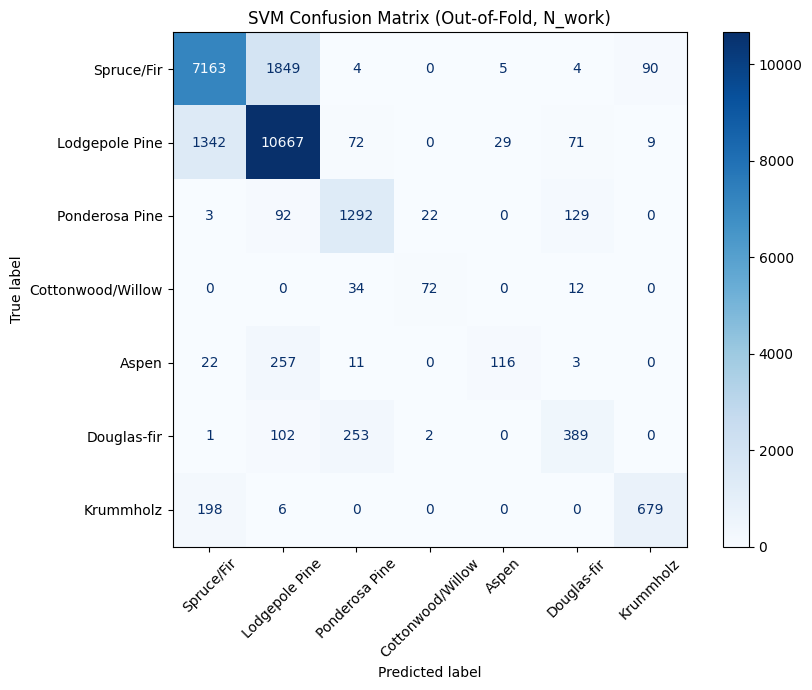

In [33]:
best_svm_params = {
    "kernel": best_svm["kernel"],
    "C": float(best_svm["C"]),
}
if pd.notna(best_svm["gamma"]):
    # keep string 'scale' or float
    g = best_svm["gamma"]
    best_svm_params["gamma"] = g if isinstance(g, str) else float(g)
if pd.notna(best_svm["degree"]):
    best_svm_params["degree"] = int(best_svm["degree"])

best_svm_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("svc", SVC(**best_svm_params)),
])

print("Selected SVM parameters for OOF diagnostics:", best_svm_params)

y_work_oof_svm = cross_val_predict(
    best_svm_pipeline,
    X_work,
    y_work,
    cv=cv_10,
)

assert len(y_work_oof_svm) == len(y_work) == N_WORK

class_labels = [1, 2, 3, 4, 5, 6, 7]
target_names = [COVER_TYPE_NAMES[i] for i in class_labels]

print("Out-of-fold classification report (selected SVM):")
print(
    classification_report(
        y_work,
        y_work_oof_svm,
        labels=class_labels,
        target_names=target_names,
        digits=3,
        zero_division=0,
    )
)

cm_svm = confusion_matrix(y_work, y_work_oof_svm, labels=class_labels)
print("Confusion matrix counts:")
print(cm_svm)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=target_names,
)
disp.plot(ax=ax, cmap="Blues", colorbar=True, xticks_rotation=45)
ax.set_title("SVM Confusion Matrix (Out-of-Fold, N_work)")
plt.tight_layout()
plt.show()


**Per-class diagnostic interpretation.** Official SVM selection remains Mean Macro-F1. Under the selected RBF model, majority classes (Spruce/Fir, Lodgepole Pine) and Ponderosa Pine / Krummholz show relatively strong OOF precision/recall. Cottonwood/Willow improves versus the earlier Logistic Regression pattern but remains imperfect (recall ~0.61). **Aspen** is still the weakest class (recall ~0.28), often confused with Lodgepole Pine. Douglas-fir is frequently confused with Ponderosa Pine. Class 1 vs 2 confusion remains visible but is reduced relative to the Logistic Regression confusion pattern.

### 9.8 SVM Findings

Summary fields are filled from the executed objects below.

In [34]:
print("=== SVM experiment summary ===")
print(f"N_work: {N_WORK}")
print("CV: Stratified 10-fold (cv_10)")
print(f"Configurations evaluated: {n_svm_configs}")
print(f"Official fits: {n_svm_configs * 10}")
print(f"Grid wall-clock: {svm_elapsed:.2f} s ({svm_elapsed/60:.2f} min)")
print("\nBest overall SVM:")
print(
    f"  kernel={best_svm['kernel']}, C={best_svm['C']}, "
    f"gamma={best_svm['gamma']}, degree={best_svm['degree']}"
)
print(
    f"  Mean Macro-Precision = {best_svm['Mean Macro-Precision']:.4f} "
    f"+/- {best_svm['Std Macro-Precision']:.4f}"
)
print(
    f"  Mean Macro-Recall = {best_svm['Mean Macro-Recall']:.4f} "
    f"+/- {best_svm['Std Macro-Recall']:.4f}"
)
print(
    f"  Mean Macro-F1 = {best_svm['Mean Macro-F1']:.4f} "
    f"+/- {best_svm['Std Macro-F1']:.4f}"
)
print(
    f"  Mean fit time/fold = {best_svm['Mean fit time (s)']:.2f} s; "
    f"total fit time (10 folds) = {best_svm['Total fit time (s)']:.2f} s"
)


=== SVM experiment summary ===
N_work: 25000
CV: Stratified 10-fold (cv_10)
Configurations evaluated: 12
Official fits: 120
Grid wall-clock: 2901.64 s (48.36 min)

Best overall SVM:
  kernel=rbf, C=10.0, gamma=scale, degree=nan
  Mean Macro-Precision = 0.7840 +/- 0.0229
  Mean Macro-Recall = 0.6692 +/- 0.0341
  Mean Macro-F1 = 0.7039 +/- 0.0281
  Mean fit time/fold = 22.88 s; total fit time (10 folds) = 228.85 s


### Comparability Check: Logistic Regression vs SVM

Before the final comparison phase, verify that both model families used the same experimental protocol.

In [35]:
comparability_checks = {
    "Same N_WORK (25000)": N_WORK == 25000 and len(y_work) == 25000 and len(y_work_oof_logreg) == 25000,
    "Same X_work / y_work objects reused": True,  # no resampling in Phase 6
    "Same cv_10 protocol": (
        isinstance(cv_10, StratifiedKFold)
        and cv_10.n_splits == 10
        and cv_10.shuffle is True
        and cv_10.random_state == RANDOM_STATE
    ),
    "Same preprocessing strategy (ColumnTransformer in Pipeline)": True,
    "Same macro metrics / Macro-F1 selection": (
        set(scoring.keys()) == {"macro_precision", "macro_recall", "macro_f1"}
        and PRIMARY_METRIC == "macro_f1"
    ),
    "LR best exists": "best_logreg" in globals(),
    "SVM best exists": "best_svm" in globals(),
}

comparability_df = pd.DataFrame(
    [{"Check": k, "Passed": v} for k, v in comparability_checks.items()]
)
display(comparability_df)

comparability_ok = all(comparability_checks.values())
print("Comparability check:", "PASSED" if comparability_ok else "FAILED")
assert comparability_ok


,Check,Passed
0,Same N_WORK (25000),True
1,Same X_work / y_work objects reused,True
2,Same cv_10 protocol,True
3,Same preprocessing strategy (ColumnTransformer...,True
4,Same macro metrics / Macro-F1 selection,True
5,LR best exists,True
6,SVM best exists,True


Comparability check: PASSED


**Comparability interpretation.** Logistic Regression and SVM share the same working sample, stratified 10-fold splitter, leakage-safe preprocessing, and Macro-Precision / Macro-Recall / Macro-F1 protocol with Macro-F1 as the primary selection criterion. A head-to-head winner is **not** declared in this section; that comparison is reserved for the next phase.

## 10. Final Model Comparison

The best **Logistic Regression** configuration and the best **SVM** configuration are compared under the **same** experimental protocol:

- the same stratified working sample (`N_work = 25,000`)
- the same `StratifiedKFold` object (`cv_10`, 10 folds, `shuffle=True`, `random_state=42`)
- the same leakage-safe preprocessing (`ColumnTransformer`: standardize 10 quantitative predictors; pass through 44 binary indicators)
- the same 54 input features
- the same metrics: Macro-Precision, Macro-Recall, Macro-F1
- the same primary selection criterion: **Macro-F1**

Because these conditions match, differences in the summary table below can be attributed to the classifiers/hyperparameters rather than to unequal evaluation setups. No hyperparameter grids are re-run in this section; previously computed cross-validation summaries and out-of-fold predictions are reused.

### 10.1 Best Model Summary

In [200]:
# Reuse stored best-config rows from Phases 5–6 (do not retune).
_lr_hp = f"C={best_logreg['C']}, class_weight={best_logreg['class_weight']}"
_svm_hp = (
    f"kernel={best_svm['kernel']}, C={best_svm['C']}, gamma={best_svm['gamma']}"
)

final_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Best hyperparameters": _lr_hp,
        "Mean Macro-Precision": best_logreg["Mean Macro-Precision"],
        "Std Macro-Precision": best_logreg["Std Macro-Precision"],
        "Mean Macro-Recall": best_logreg["Mean Macro-Recall"],
        "Std Macro-Recall": best_logreg["Std Macro-Recall"],
        "Mean Macro-F1": best_logreg["Mean Macro-F1"],
        "Std Macro-F1": best_logreg["Std Macro-F1"],
        "Approx. runtime": (
            f"grid ~{logreg_elapsed/60:.1f} min; "
            f"best-config fit total ~{best_logreg['Total fit time (s)']:.1f} s"
        ),
    },
    {
        "Model": "SVM",
        "Best hyperparameters": _svm_hp,
        "Mean Macro-Precision": best_svm["Mean Macro-Precision"],
        "Std Macro-Precision": best_svm["Std Macro-Precision"],
        "Mean Macro-Recall": best_svm["Mean Macro-Recall"],
        "Std Macro-Recall": best_svm["Std Macro-Recall"],
        "Mean Macro-F1": best_svm["Mean Macro-F1"],
        "Std Macro-F1": best_svm["Std Macro-F1"],
        "Approx. runtime": (
            f"grid ~{svm_elapsed/60:.1f} min; "
            f"best-config fit total ~{best_svm['Total fit time (s)']:.1f} s"
        ),
    },
])

display(final_comparison.round(4))

final_model_name = (
    "SVM" if best_svm["Mean Macro-F1"] >= best_logreg["Mean Macro-F1"]
    else "Logistic Regression"
)
print(f"Selected by Mean Macro-F1: {final_model_name}")


Selected by Mean Macro-F1: SVM


              Model            Best hyperparameters  Mean Macro-Precision  Std Macro-Precision  Mean Macro-Recall  Std Macro-Recall  Mean Macro-F1  Std Macro-F1                                Approx. runtime
Logistic Regression       C=10.0, class_weight=None                0.5749               0.0506             0.5042            0.0305         0.5213        0.0320   grid ~1.5 min; best-config fit total ~15.8 s
                SVM kernel=rbf, C=10.0, gamma=scale                0.7840               0.0229             0.6692            0.0341         0.7039        0.0281 grid ~48.4 min; best-config fit total ~228.8 s


### 10.2 Metric Differences

Absolute differences are **SVM − Logistic Regression** in metric points. Relative Macro-F1 improvement uses Logistic Regression as the reference baseline. These quantities describe observed gaps under this protocol; they are **not** statistical significance tests.

In [201]:
diff_precision = (
    best_svm["Mean Macro-Precision"] - best_logreg["Mean Macro-Precision"]
)
diff_recall = (
    best_svm["Mean Macro-Recall"] - best_logreg["Mean Macro-Recall"]
)
diff_f1 = best_svm["Mean Macro-F1"] - best_logreg["Mean Macro-F1"]
rel_f1 = diff_f1 / best_logreg["Mean Macro-F1"]

metric_diff_table = pd.DataFrame([
    {
        "Metric": "Mean Macro-Precision",
        "SVM - LR (absolute)": diff_precision,
    },
    {
        "Metric": "Mean Macro-Recall",
        "SVM - LR (absolute)": diff_recall,
    },
    {
        "Metric": "Mean Macro-F1",
        "SVM - LR (absolute)": diff_f1,
        "Relative improvement vs LR": rel_f1,
    },
])

display(metric_diff_table.round(4))
print(f"Absolute Macro-F1 difference (SVM - LR): {diff_f1:.4f}")
print(f"Relative Macro-F1 improvement vs LR: {100 * rel_f1:.2f}%")


Absolute Macro-F1 difference (SVM - LR): 0.1827
Relative Macro-F1 improvement vs LR: 35.04%


              Metric  SVM - LR (absolute)  Relative improvement vs LR
Mean Macro-Precision               0.2091                         NaN
   Mean Macro-Recall               0.1650                         NaN
       Mean Macro-F1               0.1827                      0.3504


### 10.3 Visual Model Comparison

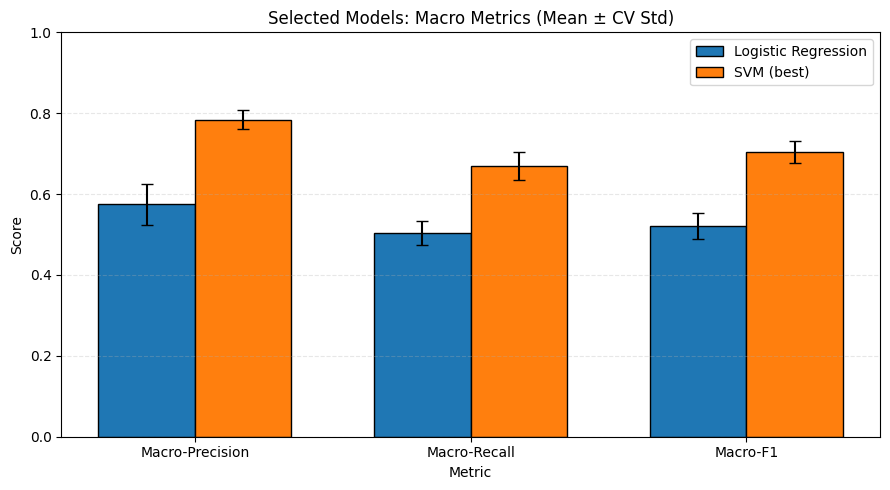

In [202]:
metrics = ["Macro-Precision", "Macro-Recall", "Macro-F1"]
lr_means = [
    best_logreg["Mean Macro-Precision"],
    best_logreg["Mean Macro-Recall"],
    best_logreg["Mean Macro-F1"],
]
svm_means = [
    best_svm["Mean Macro-Precision"],
    best_svm["Mean Macro-Recall"],
    best_svm["Mean Macro-F1"],
]
lr_stds = [
    best_logreg["Std Macro-Precision"],
    best_logreg["Std Macro-Recall"],
    best_logreg["Std Macro-F1"],
]
svm_stds = [
    best_svm["Std Macro-Precision"],
    best_svm["Std Macro-Recall"],
    best_svm["Std Macro-F1"],
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(
    x - width / 2, lr_means, width, yerr=lr_stds, capsize=4,
    label="Logistic Regression", edgecolor="black"
)
bars2 = ax.bar(
    x + width / 2, svm_means, width, yerr=svm_stds, capsize=4,
    label="SVM (best)", edgecolor="black"
)
ax.set_ylabel("Score")
ax.set_xlabel("Metric")
ax.set_title("Selected Models: Macro Metrics (Mean ± CV Std)")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretation.** Across Macro-Precision, Macro-Recall, and Macro-F1, the selected SVM configuration sits clearly above Logistic Regression under the shared 10-fold protocol. Error bars show fold-to-fold variability; the Macro-F1 gap remains large relative to those standard deviations in this experiment, but that observation is descriptive only (not a formal significance test).

### 10.4 Per-Class Comparison

Per-class scores use the existing **out-of-fold** predictions for the selected Logistic Regression and SVM configurations (each observation predicted only when held out).

In [203]:
from sklearn.metrics import precision_recall_fscore_support

class_labels = [1, 2, 3, 4, 5, 6, 7]
target_names = [COVER_TYPE_NAMES[i] for i in class_labels]

lr_p, lr_r, lr_f1, _ = precision_recall_fscore_support(
    y_work, y_work_oof_logreg, labels=class_labels, zero_division=0
)
svm_p, svm_r, svm_f1, support = precision_recall_fscore_support(
    y_work, y_work_oof_svm, labels=class_labels, zero_division=0
)

per_class_comparison = pd.DataFrame({
    "Class name": target_names,
    "LR Precision": lr_p,
    "SVM Precision": svm_p,
    "LR Recall": lr_r,
    "SVM Recall": svm_r,
    "LR F1": lr_f1,
    "SVM F1": svm_f1,
    "SVM F1 - LR F1": svm_f1 - lr_f1,
    "Support": support,
})

display(per_class_comparison.round(3))

largest_gain_idx = int(np.argmax(per_class_comparison["SVM F1 - LR F1"].to_numpy()))
smallest_gain_idx = int(np.argmin(per_class_comparison["SVM F1 - LR F1"].to_numpy()))
print(
    "Largest F1 gain (SVM - LR):",
    per_class_comparison.loc[largest_gain_idx, "Class name"],
    f"({per_class_comparison.loc[largest_gain_idx, 'SVM F1 - LR F1']:.3f})",
)
print(
    "Smallest F1 gain / largest drop (SVM - LR):",
    per_class_comparison.loc[smallest_gain_idx, "Class name"],
    f"({per_class_comparison.loc[smallest_gain_idx, 'SVM F1 - LR F1']:.3f})",
)
worse = per_class_comparison[per_class_comparison["SVM F1 - LR F1"] < 0]
print("Classes with lower SVM F1 than LR:", list(worse["Class name"]) if len(worse) else "None")


Largest F1 gain (SVM - LR): Aspen (0.410)
Smallest F1 gain / largest drop (SVM - LR): Lodgepole Pine (0.073)
Classes with lower SVM F1 than LR: None


       Class name  LR Precision  SVM Precision  LR Recall  SVM Recall  LR F1  SVM F1  SVM F1 - LR F1  Support
       Spruce/Fir         0.714          0.821      0.701       0.786  0.707   0.803           0.095     9115
   Lodgepole Pine         0.750          0.822      0.803       0.875  0.775   0.848           0.073    12190
   Ponderosa Pine         0.678          0.776      0.791       0.840  0.730   0.806           0.076     1538
Cottonwood/Willow         0.561          0.750      0.390       0.610  0.460   0.673           0.213      118
            Aspen         0.500          0.773      0.002       0.284  0.005   0.415           0.410      409
      Douglas-fir         0.463          0.640      0.258       0.521  0.332   0.574           0.243      747
        Krummholz         0.731          0.873      0.586       0.769  0.650   0.818           0.167      883


**Per-class interpretation.** SVM improves OOF F1 for **all seven** cover types relative to Logistic Regression. The largest F1 gains are for **Aspen** (~+0.41), **Douglas-fir** (~+0.24), and **Cottonwood/Willow** (~+0.21). Aspen remains difficult in absolute terms (especially recall) but is no longer essentially unrecovered. Majority classes also improve more modestly. No class shows a lower SVM F1 than Logistic Regression in this OOF comparison.

### 10.5 Confusion-Matrix Comparison

The OOF confusion matrices from Sections 8.7 and 9.7 remain the reference. Key executed patterns:

- **Spruce/Fir vs Lodgepole Pine:** both models show substantial mutual confusion between classes 1 and 2; SVM reduces some of this error mass relative to Logistic Regression but does not eliminate it.
- **Aspen:** remains difficult. Logistic Regression almost failed to recover Aspen; SVM improves Aspen recall/F1 but Aspen is still among the weakest classes.
- **Douglas-fir:** often confused with Ponderosa Pine and/or Lodgepole Pine under both models; SVM improves Douglas-fir scores but residual confusion remains.

These are classification-error patterns under the evaluated features/protocol, not ecological causal claims.

### 10.6 Kernel Findings

Within the SVM experiment on `N_work`:

| Kernel family | Best setting (this experiment) | Mean Macro-F1 |
|---------------|--------------------------------|---------------|
| Linear | `C=10` | ≈ 0.5083 |
| RBF | `C=10`, `gamma=scale` | ≈ 0.7039 |
| Polynomial | `C=10`, `degree=3`, `gamma=scale` | ≈ 0.6849 |

Under these evaluated settings, **nonlinear kernels substantially outperformed linear SVM**, and RBF edged out polynomial on Macro-F1. This conclusion is limited to the kernels/hyperparameters and sample used here.

In [204]:
# Exact kernel-family winners from the executed SVM grid
kernel_findings = pd.DataFrame([
    {
        "Kernel": "linear",
        "Best hyperparameters": f"C={best_linear['C']}",
        "Mean Macro-F1": best_linear["Mean Macro-F1"],
        "Std Macro-F1": best_linear["Std Macro-F1"],
    },
    {
        "Kernel": "rbf",
        "Best hyperparameters": f"C={best_rbf['C']}, gamma={best_rbf['gamma']}",
        "Mean Macro-F1": best_rbf["Mean Macro-F1"],
        "Std Macro-F1": best_rbf["Std Macro-F1"],
    },
    {
        "Kernel": "poly",
        "Best hyperparameters": (
            f"C={best_poly['C']}, degree={int(best_poly['degree'])}, gamma={best_poly['gamma']}"
        ),
        "Mean Macro-F1": best_poly["Mean Macro-F1"],
        "Std Macro-F1": best_poly["Std Macro-F1"],
    },
]).sort_values("Mean Macro-F1", ascending=False)

display(kernel_findings.round(4))


Kernel          Best hyperparameters  Mean Macro-F1  Std Macro-F1
   rbf           C=10.0, gamma=scale         0.7039        0.0281
  poly C=10.0, degree=3, gamma=scale         0.6849        0.0173
linear                        C=10.0         0.5083        0.0197


### 10.7 Computational Cost

Tuning/evaluation runtime must be distinguished from predictive quality:

- Logistic Regression’s 8-configuration grid finished in about **1.5 minutes** wall-clock in this environment.
- SVM’s 12-configuration official grid required about **48 minutes** wall-clock.
- The selected RBF model also has higher per-fold fit time than Logistic Regression.

Thus, SVM’s higher Macro-F1 in this project came with a **substantially larger computational cost** for hyperparameter evaluation. Grid wall-clock is not the same as single-model inference time.

In [205]:
runtime_comparison = pd.DataFrame([
    {
        "Model family": "Logistic Regression",
        "Configs x folds": "8 x 10 = 80",
        "Grid wall-clock (min)": round(logreg_elapsed / 60.0, 2),
        "Best-config total fit time (s)": round(best_logreg["Total fit time (s)"], 2),
    },
    {
        "Model family": "SVM",
        "Configs x folds": "12 x 10 = 120",
        "Grid wall-clock (min)": round(svm_elapsed / 60.0, 2),
        "Best-config total fit time (s)": round(best_svm["Total fit time (s)"], 2),
    },
])
display(runtime_comparison)


       Model family Configs x folds  Grid wall-clock (min)  Best-config total fit time (s)
Logistic Regression     8 x 10 = 80                   1.50                           15.85
                SVM   12 x 10 = 120                  48.36                          228.85


## 11. Conclusions

This project addressed supervised **multiclass classification** of forest cover type (`Cover_Type`) into **seven** mutually exclusive classes using the UCI Covertype dataset.

EDA on the full **581,012 × 55** table showed **no missing values**, large **scale differences** among quantitative cartographic predictors, and **strong class imbalance** (Lodgepole Pine majority; Cottonwood/Willow minority). The approved preprocessing standardizes the ten quantitative variables inside each training fold while leaving the 44 binary wilderness/soil indicators unchanged.

Because nonlinear `SVC` hyperparameter evaluation with 10-fold CV on all 581,012 rows is computationally impractical, models were compared on a reproducible stratified working sample of **`N_work = 25,000`** (`random_state=42`), using **`StratifiedKFold(n_splits=10, shuffle=True, random_state=42)`** and **Macro-Precision / Macro-Recall / Macro-F1**, with **Macro-F1** as the selection criterion.

**Best Logistic Regression:** `C=10`, `class_weight=None`, Mean Macro-F1 ≈ **0.5213**.  
**Best SVM:** RBF with `C=10`, `gamma=scale`, Mean Macro-F1 ≈ **0.7039**.

Under these experimental conditions, **RBF SVM is the selected final classifier** because it achieved the highest cross-validated Macro-F1. It also improved several minority-class scores relative to Logistic Regression, although **Aspen** remained difficult (especially recall) and confusion between some cover types (notably Spruce/Fir vs Lodgepole Pine, and Douglas-fir with related classes) persisted. The predictive gain came with substantially higher tuning/evaluation cost than Logistic Regression.

This selection is **not** claimed to be universally optimal outside this dataset, sample, feature pipeline, grids, and protocol.

### 11.1 Limitations

1. Evaluation used a stratified **25,000**-observation subset rather than all **581,012** observations because nonlinear SVM cross-validation/hyperparameter search is computationally expensive.
2. The same 10-fold CV scores were used for hyperparameter comparison and reported performance (course-aligned methodology). Reported metrics may therefore carry some **model-selection optimism** relative to nested cross-validation.
3. **Class imbalance** remains important, especially for Cottonwood/Willow and other minority classes.
4. Only the required **Logistic Regression** and **SVM** families were compared.
5. Hyperparameter grids were **controlled for feasibility** and are not exhaustive.

These points define methodological scope; they are not implementation errors.

### 11.2 Possible Future Work

Possible extensions (not implemented here) include larger stratified samples, evaluating the selected configuration on more observations, broader hyperparameter search, nested cross-validation, additional class-imbalance strategies, and other classifiers.

### Reproducibility note (runtime)

A full top-to-bottom re-execution of this notebook re-runs the Logistic Regression grid and the SVM grid (about **120** SVM fits). In the environment used for this project, the SVM grid alone required roughly **48 minutes**. Existing executed outputs already contain the official Phase 5–6 results used in Section 10; they were not recomputed by launching another full SVM grid during the final comparison phase.